In [162]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

### Chargement dataset

In [3]:
df_transactions = pd.read_csv("data/transactions.csv")
df_customers = pd.read_csv("data/customers.csv")

In [15]:
print(df_customers.head())
df_customers.info()

   customer_id         country       first_purchase        last_purchase  \
0        46995  United Kingdom  2011-08-09 12:20:00  2011-11-16 12:20:00   
1        22869  United Kingdom  2010-01-11 12:20:00  2011-10-30 12:20:00   
2        12593          France  2011-05-05 09:29:00  2011-05-05 09:29:00   
3        25889  United Kingdom  2008-07-14 12:20:00  2010-02-22 12:20:00   
4        52931  United Kingdom  2009-08-29 12:20:00  2010-11-04 12:20:00   

   n_orders  total_spent  avg_basket  recency_days  tenure_days  
0      2.28        57.34       26.44         23.83        99.17  
1     46.53     19463.52      356.65         40.92       657.12  
2      1.00        39.50       39.50        218.00       218.00  
3      0.98        24.53       25.15        655.23       588.26  
4      2.00        47.80       23.18        400.35       432.64  
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  

In [14]:
print(df_transactions.head())
df_transactions.info()

  invoice_id  customer_id product_code                      product_name  \
0     513574          NaN        22382        LUNCH BAG SPACEBOY DESIGN    
1     609421          NaN        21028          PURPLE GEMSTONE BRACELET   
2     515609          NaN       47591B          SCOTTIES CHILDRENS APRON   
3     501320      15123.0        22334  DINOSAUR PARTY BAG + STICKER SET   
4     521822      12714.0        21933   PINK VINTAGE PAISLEY PICNIC BAG   

   quantity  unit_price         invoice_date         country  
0       2.0        4.21  2010-06-25 15:13:00  United Kingdom  
1       2.0        8.95  2011-10-16 12:20:00  United Kingdom  
2       1.0        1.66  2010-07-13 15:44:00  United Kingdom  
3       8.0        1.65  2010-03-16 09:49:00  United Kingdom  
4       5.0        2.95  2010-09-09 10:37:00          France  
<class 'pandas.DataFrame'>
RangeIndex: 1837137 entries, 0 to 1837136
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   invoi

In [16]:
print("Customers shape:", df_customers.shape)
print("Transactions shape:", df_transactions.shape)

Customers shape: (50000, 9)
Transactions shape: (1837137, 8)


In [17]:
# Observation 1
# Le dataset contient 50 000 clients et 1 837 137 transactions.
# Il s'agit d'un volume conséquent côté transactions.

### période des transactions

In [18]:
df_transactions['invoice_date'].min(), df_transactions['invoice_date'].max()

('2007-07-06 12:20:00', '2011-12-09 12:50:00')

In [19]:
# Observation 2
# Les transactions couvrent la période de juillet 2007 à décembre 2011 (~4,5 ans de données).
# Cela permet d'analyser des comportements long terme et la saisonnalité.

In [20]:
df_customers['first_purchase'].min(), df_customers['last_purchase'].max()

('2007-05-18 12:20:00', '2011-12-09 12:20:00')

In [21]:
# Observation 3
# Les données clients couvrent une période de mai 2007 à décembre 2011.
# Cette période est cohérente avec celle des transactions.
# Cela suggère que les agrégations clients ont bien été construites à partir des transactions.

### valeurs manquantes

In [22]:
df_customers.isna().mean().sort_values(ascending=False)

customer_id       0.0
country           0.0
first_purchase    0.0
last_purchase     0.0
n_orders          0.0
total_spent       0.0
avg_basket        0.0
recency_days      0.0
tenure_days       0.0
dtype: float64

In [23]:
# Observation 4
# Le dataset customers ne contient aucune valeur manquante.
# Cela suggère que les données agrégées ont été préalablement nettoyées ou construites proprement.

In [24]:
df_transactions.isna().mean().sort_values(ascending=False)

customer_id     0.227668
quantity        0.008811
product_name    0.004105
invoice_id      0.000000
product_code    0.000000
unit_price      0.000000
invoice_date    0.000000
country         0.000000
dtype: float64

In [25]:
# Observation 5
# Le dataset transactions contient des valeurs manquantes, notamment :
# - customer_id : ~22.8% de valeurs manquantes (très élevé)
# - quantity : ~0.88%
# - product_name : ~0.41%
#
# L'absence de customer_id est critique car elle empêche de relier certaines transactions aux clients.
# Cela pose un problème majeur pour les analyses marketing (segmentation, CLV, etc.).

### vérifier les types problématiques

In [26]:
df_transactions['customer_id'].head(10)

0        NaN
1        NaN
2        NaN
3    15123.0
4    12714.0
5    20607.0
6        NaN
7    33347.0
8    17059.0
9        NaN
Name: customer_id, dtype: float64

In [27]:
# Observation 6
# La colonne customer_id dans transactions est de type float à cause des valeurs manquantes (NaN).
# Les identifiants sont affichés avec des décimales (ex: 15123.0), ce qui n'est pas cohérent pour un identifiant.
# Cette colonne devra être convertie en entier après traitement des valeurs manquantes.

### vérifier les doublons

In [28]:
df_customers.duplicated().sum()

np.int64(0)

In [29]:
# Observation 7
# Aucun doublon détecté dans le dataset customers.
# Cela confirme que chaque ligne correspond bien à un client unique.

In [30]:
df_transactions.duplicated().sum()

np.int64(34522)

In [31]:
# Observation 8
# Le dataset transactions contient 34 522 doublons.
# Cela représente un volume non négligeable de lignes dupliquées.
# Ces doublons peuvent biaiser les analyses (chiffre d'affaires, fréquence, etc.).
# Une décision de traitement sera nécessaire (suppression ou analyse plus fine).

### types de données problématiques

In [32]:
df_transactions['invoice_date'].dtype, df_customers['first_purchase'].dtype

(<StringDtype(storage='python', na_value=nan)>,
 <StringDtype(storage='python', na_value=nan)>)

In [33]:
# Observation 9
# Les colonnes de dates (invoice_date, first_purchase, last_purchase) sont au format string.
# Elles devront être converties en datetime pour permettre les analyses temporelles
# (saisonnalité, évolution du CA, récence, etc.).

### vérifier cohérence des types

In [34]:
df_transactions.describe()

,customer_id,quantity,unit_price
count,1.418879e+06,1.820950e+06,1.837137e+06
mean,2.241318e+04,1.122359e+01,3.902841e+00
std,1.254708e+04,1.389921e+02,9.420193e+01
min,1.234600e+04,-8.099500e+04,-5.359436e+04
25%,1.489500e+04,1.000000e+00,1.250000e+00
50%,1.749100e+04,4.000000e+00,2.100000e+00
75%,2.179900e+04,1.200000e+01,3.750000e+00
max,6.344100e+04,8.099500e+04,3.897000e+04


In [35]:
# Observation 10
# Présence de valeurs aberrantes dans les variables numériques :
#
# - quantity : valeurs négatives très importantes (min ≈ -80 995)
# - unit_price : valeurs négatives également (min ≈ -53 594)
#
# Ces valeurs sont incohérentes dans un contexte classique de vente.
# Elles suggèrent des cas métier spécifiques (retours, remboursements, corrections).

### 🎯 FIN ÉTAPE 1 — Data Quality Report ✅

In [37]:
# Data Quality Report (Résumé)

# 1. Dataset volumineux (1.8M transactions, 50k clients)
# 2. Données couvrant 2007 à 2011 (cohérence clients / transactions)
# 3. Pas de valeurs manquantes dans customers
# 4. Forte proportion de customer_id manquants dans transactions (~23%)
# 5. Dates au mauvais format (string)
# 6. Doublons présents dans transactions (~34k lignes)
# 7. customer_id mal typé (float)
# 8. Valeurs négatives dans quantity et unit_price (cas métier probable)

### 🔎 Problème 1 : customer_id manquants

In [38]:
df_transactions[df_transactions['customer_id'].isna()].head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
6,503061,NaN,22381,TOY TIDY PINK RETROSPOT,84.0,4.95,2010-03-29 16:47:00,United Kingdom
9,756479,NaN,35972,PINK METAL CHICKEN HEART,24.0,1.49,2010-11-29 12:20:00,Czech Republic


In [39]:
df_transactions[df_transactions['customer_id'].isna()]['invoice_id'].nunique()

110589

In [40]:
# Traitement 1 - customer_id manquants

# Les transactions sans customer_id représentent un volume important (~110k factures).
# Elles correspondent probablement à des clients non identifiés (guest) ou à des données CRM incomplètes.

# Ces lignes ne peuvent pas être utilisées pour une analyse client (segmentation, fréquence, CLV).
# Nous décidons donc de les exclure de l’analyse.

df_transactions = df_transactions.dropna(subset=['customer_id'])

### les valeurs négatives (quantity)

In [41]:
df_transactions[df_transactions['quantity'] < 0].head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
20,C548723,15874.0,72741,GRAND CHOCOLATECANDLE,-3.0,1.45,2011-04-04 09:02:00,United Kingdom
69,C535276,15021.0,82483,WOOD 2 DRAWER CABINET WHITE FINISH,-6.0,5.95,2010-11-25 13:56:00,United Kingdom
123,C562221,16525.0,22151,PLACE SETTING WHITE HEART,-432.0,0.36,2011-08-03 14:22:00,United Kingdom
224,C573228,16764.0,23148,MINIATURE ANTIQUE ROSE HOOK IVORY,-1.0,0.83,2011-10-28 11:54:00,United Kingdom
227,C573219,14415.0,21672,WHITE SPOT RED CERAMIC DRAWER KNOB,-1.0,1.45,2011-10-28 11:49:00,United Kingdom


In [42]:
# Traitement 2 - quantités négatives (retours)

# Les quantités négatives correspondent à des retours produits
# (invoice_id commençant par "C").

# Pour une analyse marketing centrée sur les achats,
# nous excluons ces transactions.

df_transactions = df_transactions[df_transactions['quantity'] > 0]

### les unit_price à 0 ou négatifs

In [43]:
df_transactions[df_transactions['unit_price'] <= 0].head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
136,734573,44742.0,21145,CHARLIE + LOLA RED HOT WATER BOTTLE,1.0,0.0,2010-12-29 12:20:00,United Kingdom
585,656137,22097.0,22156,3 GARDENIA MORRIS BOXED CANDLES,4.0,0.0,2010-07-11 12:20:00,United Kingdom
842,758411,55770.0,20659,"GREETING CARD, OVERCROWDED POOL.",12.0,0.0,2011-10-20 12:20:00,United Kingdom
2617,681016,28378.0,22467,HANGING HEART ZINC T-LIGHT HOLDER,12.0,0.0,2010-11-10 12:20:00,United Kingdom
2646,745623,50314.0,84033,PINK HAPPY BIRTHDAY BUNTING,50.0,0.0,2011-05-15 12:20:00,United Kingdom


In [44]:
# Traitement 3 - unit_price à 0

# Les prix à 0 correspondent probablement à des produits offerts ou des promotions.
# Ils ne génèrent pas de chiffre d'affaires et peuvent biaiser les analyses de panier moyen.

# Nous décidons de les exclure pour une analyse marketing centrée sur les achats réels.

df_transactions = df_transactions[df_transactions['unit_price'] > 0]

### les product_code atypiques

In [45]:
df_transactions['product_code'].value_counts().head(10)

product_code
85123A    9347
85099B    6023
22423     3582
82494L    3325
84879     2883
20725     2823
21212     2806
85099F    2800
85099C    2666
21034     2276
Name: count, dtype: int64

In [46]:
df_transactions[df_transactions['product_code'].str.contains('[A-Za-z]', regex=True)]['product_code'].value_counts().head(20)

product_code
85123A    9347
85099B    6023
82494L    3325
85099F    2800
85099C    2666
84970S    2110
POST      1962
84029E    1929
47591D    1925
84997D    1876
84997B    1690
84997C    1666
15056N    1555
84970L    1504
47590B    1474
84029G    1467
85014B    1424
84406B    1358
85049E    1295
47566B    1230
Name: count, dtype: int64

In [47]:
# Traitement 4 - codes non produits

# Le code 'POST' correspond à des frais de port et non à un produit.
# Il ne doit pas être inclus dans une analyse du comportement d'achat produit.

df_transactions = df_transactions[df_transactions['product_code'] != 'POST']

### line_total = quantity * unit_price

In [48]:
df_transactions['line_total'] = df_transactions['quantity'] * df_transactions['unit_price']
df_transactions[['quantity', 'unit_price', 'line_total']].head()

,quantity,unit_price,line_total
3,8.0,1.65,13.20
4,5.0,2.95,14.75
7,60.0,0.65,39.00
8,1.0,2.08,2.08
10,12.0,1.95,23.40


In [49]:
# Observation 11
# Le calcul line_total = quantity × unit_price est cohérent sur les premières lignes.
# Aucune anomalie visible dans le calcul.

### 🎯 BILAN ÉTAPE 2 — Nettoyage transactions ✅

In [50]:
# Résumé nettoyage transactions

# 1. Suppression des transactions sans customer_id (non exploitables pour analyse client)
# 2. Suppression des retours (quantity < 0)
# 3. Suppression des lignes avec unit_price = 0 (produits offerts)
# 4. Suppression des frais de port (product_code = 'POST')
# 5. Création de la variable line_total

### EDA marketing

In [53]:
df_transactions['customer_id'].nunique(), df_transactions['invoice_id'].nunique()

(48861, 218551)

In [54]:
# Observation 12
# Après nettoyage :
# - 48 861 clients uniques
# - 218 551 transactions (factures)
#
# Une partie des clients a été exclue via la suppression des transactions sans customer_id.

### Distribution des achats

In [55]:
basket_per_invoice = df_transactions.groupby('invoice_id')['line_total'].sum()

basket_per_invoice.describe()

count    218551.000000
mean        142.675920
std         613.870354
min           0.120000
25%          17.850000
50%          42.500000
75%         120.000000
max      168469.600000
Name: line_total, dtype: float64

In [56]:
# Observation 13
# Le panier moyen est d’environ 142.7
# La médiane est beaucoup plus faible (~42.5)
# Le 75e percentile est à 120
#
# La valeur maximale est extrêmement élevée (~168 469),
# ce qui indique la présence d'outliers importants.

### détecter les outliers

In [57]:
basket_per_invoice.sort_values(ascending=False).head(10)

invoice_id
581483    168469.60
541431     77183.60
493819     44051.60
556444     38970.00
524181     33167.80
537659     31770.98
567423     31698.16
526934     26007.08
515944     22863.36
556917     22775.93
Name: line_total, dtype: float64

In [58]:
# Observation 14
# Présence de paniers extrêmement élevés (jusqu'à ~168k).
# Ces valeurs correspondent probablement à des clients B2B ou achats en gros volume.
#
# Nous décidons de les conserver mais de les considérer comme des outliers
# qui peuvent biaiser certaines analyses (notamment la moyenne).

### loi de Pareto

In [59]:
ca_per_customer = df_transactions.groupby('customer_id')['line_total'].sum()

ca_per_customer = ca_per_customer.sort_values(ascending=False)

cum_pct = ca_per_customer.cumsum() / ca_per_customer.sum()

cum_pct.head(10)

customer_id
18102.0    0.019525
14646.0    0.036418
14156.0    0.046486
14911.0    0.055978
17450.0    0.063898
13694.0    0.070199
17511.0    0.075831
16446.0    0.081234
16684.0    0.085952
12415.0    0.090574
Name: line_total, dtype: float64

In [60]:
(cum_pct <= 0.8).sum()

np.int64(6435)

In [61]:
# Observation 15
# Environ 6 435 clients génèrent 80% du chiffre d'affaires.

In [62]:
6435 / 48861

0.13170012893718916

In [63]:
# Observation 16
# Environ 13% des 'clients génèrent 80% du chiffre d'affaires.
#
# Cela indique une forte concentration du revenu sur une minorité de clients.

In [64]:
# Insight business clé - Pareto

# Environ 13% des clients génèrent 80% du chiffre d'affaires.
# Cela révèle une forte concentration de la valeur sur une minorité de clients.
#
# Implication marketing :
# Ces clients doivent être priorisés dans les stratégies de fidélisation
# et de maximisation de la valeur (upsell, cross-sell).

### fréquence d’achat

In [65]:
orders_per_customer = df_transactions.groupby('customer_id')['invoice_id'].nunique()

orders_per_customer.describe()

count    48861.000000
mean         4.473056
std          9.529582
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        398.000000
Name: invoice_id, dtype: float64

In [66]:
# Observation 17
# Le nombre moyen de commandes par client est d’environ 4.47
# La médiane est de 2 commandes
#
# 25% des clients n'ont qu'1 seule commande
# 75% des clients ont au maximum 5 commandes
#
# Certains clients ont un nombre très élevé de commandes (max = 398)

In [67]:
# Insight fréquence

# Une grande partie des clients effectue peu d’achats :
# - 25% des clients n’ont qu’une seule commande
# - médiane à 2 commandes
#
# Cela indique un fort taux de clients occasionnels,
# avec un potentiel important de réactivation.
#
# À l’inverse, une minorité de clients très actifs génère une forte valeur.

### segmentation naturelle

In [68]:
(orders_per_customer == 1).mean()

np.float64(0.4176336955854362)

In [69]:
# Observation 18
# Environ 41.7% des clients n'ont effectué qu'une seule commande.

In [70]:
# Insight rétention

# Environ 41.7% des clients n'ont effectué qu'une seule commande.
#
# Cela révèle un fort taux de clients non récurrents,
# indiquant un problème potentiel de fidélisation.
#
# Implication marketing :
# Mettre en place des stratégies de réactivation et de fidélisation
# pour augmenter la lifetime value des clients.

### Saisonnalité du chiffre d’affaires

In [72]:
df_transactions['invoice_date'] = pd.to_datetime(df_transactions['invoice_date'])

ca_monthly = df_transactions.set_index('invoice_date').resample('ME')['line_total'].sum()

ca_monthly.head()

invoice_date
2007-07-31     62.75
2007-08-31    236.80
2007-09-30    522.65
2007-10-31    955.08
2007-11-30    583.67
Freq: ME, Name: line_total, dtype: float64

In [73]:
# Observation 19
# Le chiffre d'affaires mensuel a été correctement agrégé.
# Les données sont maintenant prêtes pour l’analyse de la saisonnalité.

### VISUALISATION

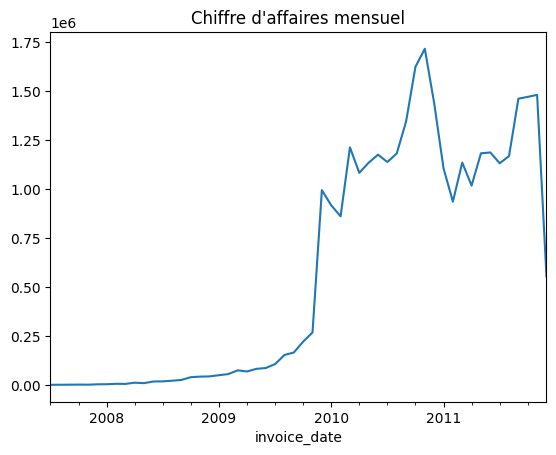

In [75]:
ca_monthly.plot()
plt.title("Chiffre d'affaires mensuel")
plt.show()

In [76]:
# Observation 20
# Le chiffre d'affaires montre une forte croissance entre 2007 et 2010.
# On observe ensuite une stabilisation avec des fluctuations.
#
# Des pics importants apparaissent, suggérant une saisonnalité marquée.
#
# Une chute brutale est visible à la fin (probablement due à une période incomplète).

In [77]:
# Insight saisonnalité

# Le chiffre d'affaires montre une forte croissance jusqu'en 2010,
# suivie d'une phase plus stable avec des fluctuations.
#
# Des pics récurrents suggèrent une saisonnalité importante,
# probablement liée à des événements commerciaux (ex: fin d’année).
#
# La chute observée en fin de période est probablement due à des données incomplètes.
#
# Implication marketing :
# Adapter les campagnes aux périodes fortes et anticiper la demande.

In [78]:
df_transactions['month'] = df_transactions['invoice_date'].dt.month
df_transactions.groupby('month')['line_total'].mean().sort_values(ascending=False)

month
1     24.584447
8     23.663063
9     23.534600
12    23.380586
6     23.065810
3     23.015186
5     22.667050
4     22.654058
2     22.515249
7     22.504833
10    21.658094
11    19.799932
Name: line_total, dtype: float64

In [79]:
# Observation 21
# Les mois avec le panier moyen le plus élevé sont :
# Janvier (1), Août (8), Septembre (9) et Décembre (12).
#
# Novembre (11) et Octobre (10) sont plus faibles.

In [80]:
# Insight saisonnalité (panier moyen)

# Le panier moyen reste relativement stable au cours de l’année,
# avec quelques variations selon les mois.
#
# Cela suggère que la saisonnalité impacte davantage le volume d’achats
# que le montant moyen par transaction.

### Géographie

In [81]:
df_customers['country'].value_counts(normalize=True).head(10)

country
United Kingdom    0.91008
Germany           0.01976
France            0.01452
Spain             0.00620
Belgium           0.00562
Portugal          0.00408
Switzerland       0.00360
Netherlands       0.00316
Italy             0.00298
Norway            0.00284
Name: proportion, dtype: float64

In [82]:
# Observation 22
# Le dataset est très fortement dominé par le Royaume-Uni (~91% des clients).
#
# Les autres pays sont très minoritaires (tous < 2%).

In [83]:
# Insight géographique

# Le dataset est fortement biaisé géographiquement :
# environ 91% des clients proviennent du Royaume-Uni.
#
# Les autres pays sont très peu représentés.
#
# Implication :
# Les analyses et segments obtenus reflètent principalement
# le comportement des clients britanniques et ne sont pas généralisables.

### relations entre variables

In [84]:
customer_metrics = df_transactions.groupby('customer_id').agg({
    'invoice_id': 'nunique',
    'line_total': 'mean'
}).rename(columns={
    'invoice_id': 'frequency',
    'line_total': 'avg_basket'
})

customer_metrics.corr()

,frequency,avg_basket
frequency,1.000000,0.006364
avg_basket,0.006364,1.000000


In [85]:
# Observation 23
# La corrélation entre fréquence d'achat et panier moyen est très faible (~0.006).
#
# Cela indique qu'il n'existe pas de relation linéaire significative entre ces deux variables.

In [86]:
# Insight relation variables

# Il n'existe pas de corrélation linéaire significative entre la fréquence d'achat
# et le panier moyen.
#
# Cela suggère que ces deux dimensions sont indépendantes
# et doivent être analysées séparément.
#
# Implication marketing :
# Il est pertinent de segmenter les clients selon plusieurs axes
# (fréquence, valeur) plutôt que de supposer un comportement homogène.

### 🚀 DERNIÈRE ÉTAPE — Hypothèses marketing

**🧾 Data Quality & Nettoyage**
-------------------------------

-   Dataset volumineux (1.8M transactions, 50k clients)

-   Données couvrant ~2007 à 2011

-   Aucune valeur manquante dans customers

-   ~23% de customer_id manquants dans transactions → supprimés

-   Présence de retours (quantity < 0) → exclus

-   Présence de prix à 0 → exclus

-   Frais de port (POST) → exclus

-   Données maintenant cohérentes pour analyse marketing

* * * * *

**📊 Insights clés**
--------------------

### **💰 1. Concentration du chiffre d'affaires (Pareto)**

-   13% des clients génèrent 80% du CA

    👉 Forte dépendance à une minorité de clients

* * * * *

### **🔁 2. Problème de rétention**

-   ~41.7% des clients = 1 seule commande

    👉 Faible fidélisation

* * * * *

### **📦 3. Distribution des paniers**

-   Moyenne >> médiane → asymétrie

-   Présence d'outliers (B2B)

* * * * *

### **📈 4. Saisonnalité**

-   Pics de CA visibles

    👉 dépendance à certaines périodes

* * * * *

### **🌍 5. Biais géographique**

-   ~91% des clients au UK

    👉 résultats non généralisables

* * * * *

### **🔗 6. Comportement client**

-   Fréquence ≠ panier (corrélation ≈ 0)

    👉 comportements distincts

* * * * *

**💡 Hypothèses marketing**
---------------------------

1.  Les clients à forte valeur doivent être ciblés en priorité (fidélisation, upsell)

2.  Un problème de rétention existe → stratégies de réactivation nécessaires

3.  Les ventes dépendent de périodes clés → optimisation des campagnes saisonnières

4.  Les clients ont des profils différents → segmentation RFM recommandée

5.  Les analyses sont biaisées UK → stratégies à adapter géographiquement

# TP2

### RFM

In [87]:
snapshot_date = df_transactions['invoice_date'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [88]:
# Observation 1
# La snapshot date est fixée au 10 décembre 2011.
# Elle correspond au lendemain de la dernière transaction du dataset.
#
# Cela permet de calculer correctement la récence pour tous les clients.

### Construction RFM

In [89]:
rfm = df_transactions.groupby('customer_id').agg({
    'invoice_date': lambda x: (snapshot_date - x.max()).days,
    'invoice_id': 'nunique',
    'line_total': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']

rfm.head()

,recency,frequency,monetary
customer_id,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,1658.40
12349.0,19,3,3678.69
12350.0,310,1,294.40


In [90]:
# Observation 2
# Les variables RFM ont été correctement calculées :
# - Recency : nombre de jours depuis le dernier achat
# - Frequency : nombre de commandes
# - Monetary : chiffre d'affaires total
#
# Les valeurs semblent cohérentes (clients récents vs anciens, petits vs gros acheteurs).

### Distribution RFM

In [91]:
rfm.describe()

,recency,frequency,monetary
count,48861.000000,48861.000000,48861.000000
mean,360.019443,4.473056,638.176973
std,316.942814,9.529582,5253.268906
min,1.000000,1.000000,0.190000
25%,88.000000,1.000000,29.350000
50%,270.000000,2.000000,86.100000
75%,567.000000,5.000000,333.500000
max,1618.000000,398.000000,608821.650000


In [92]:
# Observation 3
# Les distributions RFM sont fortement asymétriques :
#
# - Recency : médiane (270) << max (1618) → clients très inactifs présents
# - Frequency : médiane (2) << max (398) → quelques clients très actifs
# - Monetary : médiane (~86) << max (~608k) → présence d'outliers extrêmes

### SCORING RFM

In [93]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

rfm.head()

,recency,frequency,monetary,R_score,F_score,M_score
customer_id,,,,,,
12346.0,326,12,77556.46,3,5,5
12347.0,2,8,5633.32,5,5,5
12348.0,75,5,1658.40,4,4,5
12349.0,19,3,3678.69,5,3,5
12350.0,310,1,294.40,3,1,4


In [94]:
# Observation 4
# Les scores RFM ont été correctement attribués de 1 à 5.
#
# - R_score : plus élevé = client récent
# - F_score : plus élevé = client fréquent
# - M_score : plus élevé = client à forte valeur

### créer le score RFM global

In [95]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
customer_id,,,,,,,
12346.0,326,12,77556.46,3,5,5,355
12347.0,2,8,5633.32,5,5,5,555
12348.0,75,5,1658.40,4,4,5,445
12349.0,19,3,3678.69,5,3,5,535
12350.0,310,1,294.40,3,1,4,314


In [96]:
# Observation 5
# Le score RFM global a été correctement construit (ex: 555, 314, etc.)
# permettant d’identifier facilement les segments clients.

### Analyse des segments clés

In [97]:
rfm['RFM_score'].value_counts().head(10)

RFM_score
555    3409
111    2598
455    1915
112    1875
211    1490
521    1172
344    1169
123    1121
421    1084
454     965
Name: count, dtype: int64

In [98]:
3409 / len(rfm)

0.06976934569493051

In [99]:
# Observation 6
# Les clients "Champions" (score 555) représentent environ 7% de la base client.

### PART DU CA

In [100]:
ca_total = rfm['monetary'].sum()

ca_champions = rfm[rfm['RFM_score'] == '555']['monetary'].sum()

ca_champions / ca_total

np.float64(0.5480945701866006)

In [101]:
# Observation 7
# Les clients "Champions" (7% de la base) génèrent environ 54.8% du chiffre d'affaires.

In [102]:
# Insight Champions

# Les clients "Champions" représentent environ 7% de la base,
# mais génèrent près de 55% du chiffre d'affaires.
#
# Cela révèle une très forte concentration de la valeur.
#
# Implication marketing :
# Ce segment doit être prioritaire (fidélisation, offres personnalisées, programme VIP).

### Clients “Perdus” (111)

In [103]:
(rfm['RFM_score'] == '111').mean()

np.float64(0.0531712408669491)

In [104]:
# Observation 8
# Environ 5.3% des clients sont considérés comme "perdus" (score 111).

In [105]:
# Insight clients perdus

# Environ 5.3% des clients sont considérés comme "perdus" (faible récence, fréquence et montant).
#
# Ce segment a une faible valeur et un faible engagement.
#
# Implication marketing :
# Mettre en place des campagnes de réactivation à faible coût,
# ou exclure ce segment des campagnes coûteuses.

### Clients “À risque”

In [109]:
rfm[(rfm['R_score'].astype(int) <= 2) & (rfm['M_score'].astype(int) >= 4)].shape[0] / len(rfm)

0.08603999099486298

In [110]:
# Observation 9
# Environ 8.6% des clients sont "à risque"
# (faible récence mais forte valeur historique).

In [111]:
# Insight clients à risque

# Environ 8.6% des clients sont "à risque" :
# ils ont une forte valeur historique mais ne sont plus actifs récemment.
#
# Ce segment représente un enjeu stratégique majeur,
# car il s'agit de clients potentiellement rentables en cours de churn.
#
# Implication marketing :
# Mettre en place des campagnes de réactivation ciblées et personnalisées
# pour récupérer ces clients à forte valeur.

### CLUSTERING

In [112]:
rfm_enriched = rfm.copy()

rfm_enriched['avg_basket'] = rfm_enriched['monetary'] / rfm_enriched['frequency']

rfm_enriched.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,avg_basket
customer_id,,,,,,,,
12346.0,326,12,77556.46,3,5,5,355,6463.038333
12347.0,2,8,5633.32,5,5,5,555,704.165000
12348.0,75,5,1658.40,4,4,5,445,331.680000
12349.0,19,3,3678.69,5,3,5,535,1226.230000
12350.0,310,1,294.40,3,1,4,314,294.400000


In [113]:
# Observation 10
# La feature avg_basket (panier moyen par commande) a été ajoutée avec succès :
# avg_basket = monetary / frequency.
#
# Elle permettra de distinguer :
# - clients fréquents à petits paniers
# - clients occasionnels à gros paniers

### Ajouter des features comportementales demandées

In [114]:
n_products = df_transactions.groupby('customer_id')['product_code'].nunique()
n_products.head()

customer_id
12346.0     27
12347.0    126
12348.0     24
12349.0    137
12350.0     16
Name: product_code, dtype: int64

In [115]:
# Observation 11
# Le nombre de produits distincts par client a été calculé avec succès.
#
# Cette variable mesure la diversité d'achat :
# - faible valeur → achats ciblés
# - forte valeur → comportement exploratoire / large consommation

### Intégrer dans le dataset

In [116]:
rfm_enriched['n_products'] = n_products

rfm_enriched.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,avg_basket,n_products
customer_id,,,,,,,,,
12346.0,326,12,77556.46,3,5,5,355,6463.038333,27
12347.0,2,8,5633.32,5,5,5,555,704.165000,126
12348.0,75,5,1658.40,4,4,5,445,331.680000,24
12349.0,19,3,3678.69,5,3,5,535,1226.230000,137
12350.0,310,1,294.40,3,1,4,314,294.400000,16


In [117]:
# Observation 12
# La feature n_products a été intégrée avec succès au dataset enrichi.
#
# Le dataset contient maintenant :
# - RFM (recency, frequency, monetary)
# - avg_basket
# - n_products
#
# On commence à avoir une vraie base pour le clustering.

### TENURE (ancienneté)

In [118]:
tenure = df_transactions.groupby('customer_id')['invoice_date'].agg(lambda x: (snapshot_date - x.min()).days)

tenure.head()

customer_id
12346.0    726
12347.0    404
12348.0    438
12349.0    589
12350.0    310
Name: invoice_date, dtype: int64

In [119]:
# Observation 13
# La variable tenure (ancienneté client) a été correctement calculée :
# elle représente le nombre de jours entre le premier achat et la snapshot date.
#
# Elle permet de distinguer :
# - nouveaux clients
# - clients historiques

### intégrer tenure

In [120]:
rfm_enriched['tenure'] = tenure

rfm_enriched.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,avg_basket,n_products,tenure
customer_id,,,,,,,,,,
12346.0,326,12,77556.46,3,5,5,355,6463.038333,27,726
12347.0,2,8,5633.32,5,5,5,555,704.165000,126,404
12348.0,75,5,1658.40,4,4,5,445,331.680000,24,438
12349.0,19,3,3678.69,5,3,5,535,1226.230000,137,589
12350.0,310,1,294.40,3,1,4,314,294.400000,16,310


In [121]:
# Observation 14
# Le dataset enrichi contient désormais des features pertinentes pour le clustering :
#
# - recency
# - frequency
# - monetary
# - avg_basket
# - n_products
# - tenure
#
# Ces variables couvrent :
# - engagement
# - valeur
# - diversité
# - ancienneté

### Préparer X

In [122]:
features = ['recency', 'frequency', 'monetary', 'avg_basket', 'n_products', 'tenure']

X = rfm_enriched[features]

X.head()

,recency,frequency,monetary,avg_basket,n_products,tenure
customer_id,,,,,,
12346.0,326,12,77556.46,6463.038333,27,726
12347.0,2,8,5633.32,704.165000,126,404
12348.0,75,5,1658.40,331.680000,24,438
12349.0,19,3,3678.69,1226.230000,137,589
12350.0,310,1,294.40,294.400000,16,310


In [123]:
# Observation 15
# La matrice de features X est correctement construite avec 6 variables pertinentes.
#
# Les variables sont sur des échelles très différentes :
# - monetary → très grand
# - frequency → petit
# - recency → moyen
#
# Une normalisation est donc indispensable avant clustering.

### NORMALISATION

In [125]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.10733732,  0.78985846, 14.64213455, 14.22332843,  0.10096469,
         0.53165155],
       [-1.12961421,  0.37010857,  0.95087349,  1.3600287 ,  1.92379278,
        -0.53411199],
       [-0.89928639,  0.05529615,  0.19420926,  0.52802808,  0.04572747,
        -0.42157795],
       [-1.07597622, -0.1545788 ,  0.57879088,  2.52613849,  2.12632923,
         0.07820557],
       [-0.15782013, -0.36445374, -0.06544125,  0.44475766, -0.10157177,
        -0.84523551]])

In [126]:
# Observation 16
# Les données ont été correctement normalisées avec StandardScaler.
#
# Chaque variable est maintenant centrée (moyenne = 0)
# et réduite (écart-type = 1).
#
# Les features sont désormais comparables pour le clustering.

### MÉTHODE DU COUDE

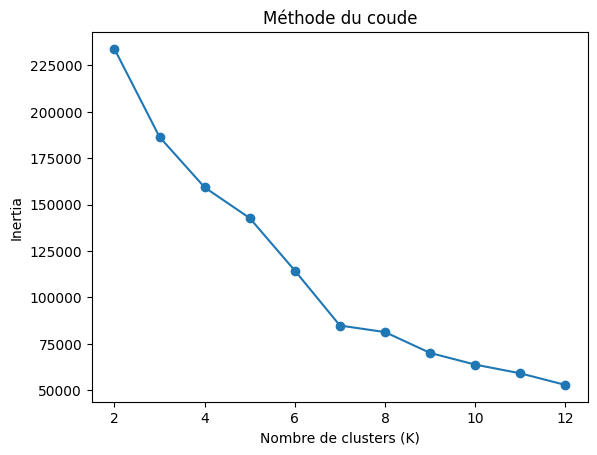

In [129]:
inertia = []

K_range = range(2, 13)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertia')
plt.title('Méthode du coude')
plt.show()

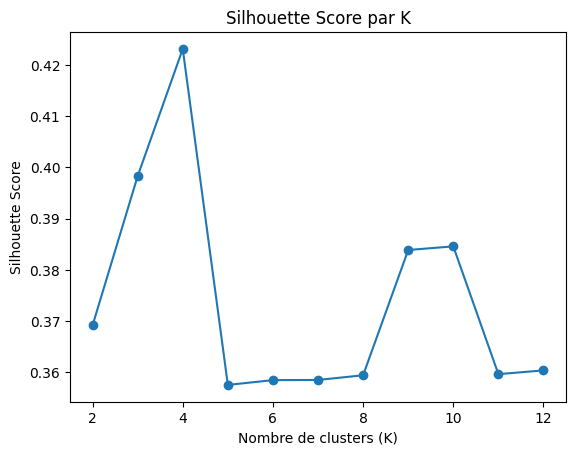

In [131]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score par K')
plt.show()

In [132]:
# Choix du nombre de clusters

# La méthode du coude suggère un K optimal autour de 6–7.
# Le score de silhouette est maximal pour K=4, mais reste acceptable pour K=6.
#
# Étant donné l'objectif marketing (segmentation fine et actionnable),
# nous choisissons K=6 afin d'obtenir des segments plus granulaires.

### Application KMeans

In [133]:
kmeans = KMeans(n_clusters=6, random_state=42)

rfm_enriched['cluster'] = kmeans.fit_predict(X_scaled)

rfm_enriched.head()

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,avg_basket,n_products,tenure,cluster
customer_id,,,,,,,,,,,
12346.0,326,12,77556.46,3,5,5,355,6463.038333,27,726,2
12347.0,2,8,5633.32,5,5,5,555,704.165000,126,404,2
12348.0,75,5,1658.40,4,4,5,445,331.680000,24,438,1
12349.0,19,3,3678.69,5,3,5,535,1226.230000,137,589,2
12350.0,310,1,294.40,3,1,4,314,294.400000,16,310,4


### Profil des clusters

In [134]:
cluster_profile = rfm_enriched.groupby('cluster')[[
    'recency', 'frequency', 'monetary', 'avg_basket', 'n_products', 'tenure'
]].mean()

cluster_profile

,recency,frequency,monetary,avg_basket,n_products,tenure
cluster,,,,,,
0,800.863386,1.693307,113.718523,58.939515,5.640079,895.378819
1,269.531855,5.364150,543.450888,99.370040,21.593682,601.378641
2,61.899671,23.924342,6199.956413,409.224166,194.684211,652.786184
3,45.643678,154.091954,33451.398069,358.730619,577.390805,745.942529
4,127.237870,2.072077,155.582765,71.820897,8.995791,187.858799
5,3.833333,149.500000,360156.293333,16611.087544,914.166667,599.666667


In [135]:
# Interprétation des clusters

# Cluster 5 : Ultra VIP → clients à très forte valeur, très actifs
# Cluster 3 : Gros clients fidèles → forte fréquence et CA élevé
# Cluster 2 : Bons clients → actifs avec bon niveau de dépense
# Cluster 1 : Clients moyens → comportement standard
# Cluster 4 : Nouveaux / faibles clients → faible engagement
# Cluster 0 : Clients dormants → inactifs depuis longtemps

# Ces segments permettent d'adapter les stratégies marketing :
# - VIP : fidélisation premium
# - Fidèles : upsell
# - Moyens : augmentation panier
# - Nouveaux : activation
# - Dormants : réactivation ou exclusion

### 📊 Comparaison RFM vs Clustering

In [136]:
pd.crosstab(rfm_enriched['RFM_score'], rfm_enriched['cluster'])

cluster,0,1,2,3,4,5
RFM_score,,,,,,
111,2598,0,0,0,0,0
112,1875,0,0,0,0,0
113,265,0,0,0,0,0
114,137,0,0,0,0,0
115,13,2,0,0,0,0
...,...,...,...,...,...,...
551,0,0,0,0,1,0
552,0,7,0,0,18,0
553,0,89,0,0,99,0


In [137]:
# Comparaison RFM vs Clustering

# Les segments RFM les plus faibles (ex: 111) sont principalement regroupés dans le cluster 0,
# ce qui montre une forte cohérence entre les deux approches pour identifier les clients dormants.

# En revanche, les clients "Champions" (555) sont répartis sur plusieurs clusters.
# Cela montre que le clustering permet une segmentation plus fine au sein d’un même groupe RFM.

# Conclusion :
# Le clustering enrichit l’analyse en capturant des dimensions supplémentaires
# (panier moyen, diversité produits, ancienneté),
# et permet une segmentation plus précise et exploitable d’un point de vue marketing.

# TP3

### Split temporel

In [138]:
df_transactions['invoice_date'] = pd.to_datetime(df_transactions['invoice_date'])

split_date = df_transactions['invoice_date'].min() + pd.DateOffset(months=12)

split_date

Timestamp('2008-07-06 12:20:00')

In [139]:
# Observation 1
# La date de split est fixée au 6 juillet 2008.
# Elle correspond à 12 mois après le début du dataset.
#
# Cela permet de séparer :
# - période passée → features
# - période future → target (CLV)

### Création des datasets

In [140]:
past_data = df_transactions[df_transactions['invoice_date'] <= split_date]
future_data = df_transactions[df_transactions['invoice_date'] > split_date]

past_data.shape, future_data.shape

((2090, 10), (1379947, 10))

In [141]:
df_transactions['invoice_date'].min(), df_transactions['invoice_date'].max()

(Timestamp('2007-07-06 12:20:00'), Timestamp('2011-12-09 12:50:00'))

In [142]:
df_transactions_clv = df_transactions.copy()

df_transactions_clv = df_transactions_clv.dropna(subset=['customer_id'])

df_transactions_clv.shape

(1382037, 10)

In [143]:
# Observation 2
# Le dataset CLV contient 1 382 037 lignes après suppression des customer_id manquants.
# Ce volume est suffisant pour construire des features robustes et entraîner des modèles.

In [144]:
df_transactions_clv['invoice_date'] = pd.to_datetime(df_transactions_clv['invoice_date'])

split_date = df_transactions_clv['invoice_date'].min() + pd.DateOffset(months=12)

past_data = df_transactions_clv[df_transactions_clv['invoice_date'] <= split_date]
future_data = df_transactions_clv[df_transactions_clv['invoice_date'] > split_date]

past_data.shape, future_data.shape

((2090, 10), (1379947, 10))

In [145]:
split_date = df_transactions_clv['invoice_date'].max() - pd.DateOffset(months=12)

split_date

Timestamp('2010-12-09 12:50:00')

In [146]:
# Observation 3
# La date de split est fixée au 9 décembre 2010.
# On utilise donc :
# - historique jusqu'au 09/12/2010 pour construire les features
# - les 12 mois suivants (jusqu'à fin 2011) comme période future à prédire (CLV)
#
# Cette approche évite un historique trop court et réduit le risque de data leakage.

In [147]:
past_data = df_transactions_clv[df_transactions_clv['invoice_date'] <= split_date]
future_data = df_transactions_clv[df_transactions_clv['invoice_date'] > split_date]

past_data.shape, future_data.shape

((735787, 10), (646250, 10))

In [148]:
# Observation 4
# Le dataset est correctement séparé :
# - past_data : 735 787 lignes (historique riche)
# - future_data : 646 250 lignes (période cible)
#
# Les deux ensembles sont suffisamment volumineux pour construire un modèle CLV robuste.

### Construction de la TARGET CLV

In [149]:
clv = future_data.groupby('customer_id')['line_total'].sum()

clv.head()

customer_id
12346.0    77183.60
12347.0     3598.21
12348.0     1437.24
12349.0     1457.55
12350.0      294.40
Name: line_total, dtype: float64

In [150]:
# Observation 5
# La CLV (Customer Lifetime Value) a été calculée comme la somme
# des dépenses sur les 12 mois futurs pour chaque client.
#
# Cette variable servira de target pour les modèles de machine learning.

### Construction des FEATURES (past_data)

In [151]:
rfm_past = past_data.groupby('customer_id').agg({
    'invoice_date': lambda x: (split_date - x.max()).days,
    'invoice_id': 'nunique',
    'line_total': 'sum'
})

rfm_past.columns = ['recency', 'frequency', 'monetary']

rfm_past['avg_basket'] = rfm_past['monetary'] / rfm_past['frequency']

rfm_past.head()

,recency,frequency,monetary,avg_basket
customer_id,,,,
12346.0,163,11,372.86,33.896364
12347.0,1,2,2035.11,1017.555000
12348.0,72,1,221.16,221.160000
12349.0,42,2,2221.14,1110.570000
12351.0,9,1,300.93,300.930000


In [152]:
# Observation 6
# Les features RFM ont été calculées sur la période passée :
# - recency : jours depuis dernier achat avant le split
# - frequency : nombre de commandes passées
# - monetary : CA passé
# - avg_basket : panier moyen
#
# Ces variables sont cohérentes et exploitables pour la prédiction de la CLV.

### Enrichir avec features clés

In [153]:
n_products = past_data.groupby('customer_id')['product_code'].nunique()

active_months = past_data.copy()
active_months['month'] = active_months['invoice_date'].dt.to_period('M')
active_months = active_months.groupby('customer_id')['month'].nunique()

rfm_past['n_products'] = n_products
rfm_past['n_active_months'] = active_months

rfm_past.head()

,recency,frequency,monetary,avg_basket,n_products,n_active_months
customer_id,,,,,,
12346.0,163,11,372.86,33.896364,26,4
12347.0,1,2,2035.11,1017.555000,70,2
12348.0,72,1,221.16,221.160000,19,1
12349.0,42,2,2221.14,1110.570000,89,2
12351.0,9,1,300.93,300.930000,21,1


In [154]:
# Observation 7
# Deux nouvelles features comportementales ont été ajoutées :
#
# - n_products : diversité des achats
# - n_active_months : régularité d'achat dans le temps
#
# Ces variables apportent une information complémentaire aux RFM
# et permettent de mieux capturer le comportement client.

### MERGE avec la CLV

In [155]:
df_model = rfm_past.merge(clv, on='customer_id', how='inner')

df_model.head()

,recency,frequency,monetary,avg_basket,n_products,n_active_months,line_total
customer_id,,,,,,,
12346.0,163,11,372.86,33.896364,26,4,77183.60
12347.0,1,2,2035.11,1017.555000,70,2,3598.21
12348.0,72,1,221.16,221.160000,19,1,1437.24
12349.0,42,2,2221.14,1110.570000,89,2,1457.55
12352.0,10,2,343.80,171.900000,18,1,2226.04


In [156]:
# Observation 8
# Le dataset final contient :
# - des variables explicatives (RFM + comportementales)
# - la target CLV (line_total futur)
#
# Chaque ligne correspond à un client avec :
# - son historique passé (features)
# - sa valeur future (CLV)

### Préparer X et y

In [157]:
X = df_model.drop(columns=['line_total'])
y = df_model['line_total']

X.shape, y.shape

((15774, 6), (15774,))

In [158]:
# Observation 9
# Le dataset de modélisation contient :
# - 15 774 clients
# - 6 variables explicatives
# - 1 target (CLV)
#
# C’est un volume cohérent pour entraîner et évaluer plusieurs modèles.

### Train/Test split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((12619, 6), (3155, 6))

In [161]:
# Observation 10
# Le dataset est correctement séparé :
# - Train : 12 619 observations
# - Test : 3 155 observations
#
# Ce split permet d’entraîner le modèle et d’évaluer ses performances
# sur des données non vues.

### Modèle 1 : Linear Regression

In [163]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse, mae, r2

(np.float64(2709.895450746595), 568.3717071845634, 0.7914303723681286)

In [164]:
# Observation 11
# Le modèle de régression linéaire donne :
# - RMSE ≈ 2710
# - MAE ≈ 568
# - R² ≈ 0.79
#
# Le modèle explique environ 79% de la variance de la CLV.

### Random Forest

In [165]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf, mae_rf, r2_rf

(np.float64(3546.325347619469), 535.2789399174402, 0.6428068296439724)

In [166]:
# Comparaison des modèles

# Le modèle de régression linéaire obtient de meilleures performances (R² ≈ 0.79)
# que le Random Forest (R² ≈ 0.64).
#
# Cela suggère que la relation entre les variables explicatives et la CLV
# est relativement linéaire.
#
# De plus, le faible nombre de features limite l’efficacité des modèles non-linéaires.
#
# Conclusion :
# La régression linéaire constitue un bon modèle de base dans ce cas.

### XGBoost

In [167]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

rmse_xgb, mae_xgb, r2_xgb

(np.float64(4269.316995082511), 557.0496701857086, 0.48231831737610065)

In [168]:
# Comparaison des modèles

# La régression linéaire obtient les meilleures performances (R² ≈ 0.79),
# devant Random Forest et XGBoost.

# Cela indique que la relation entre les variables explicatives et la CLV
# est globalement linéaire.

# Les modèles plus complexes (Random Forest, XGBoost) ne sont pas performants ici,
# probablement en raison :
# - du faible nombre de variables
# - de la nature agrégée des features
# - de l'absence de tuning

# Conclusion :
# Le modèle de régression linéaire est retenu comme modèle final.

### Quels facteurs influencent la CLV ?

In [169]:
coeffs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model_lr.coef_
}).sort_values(by='coefficient', ascending=False)

coeffs

,feature,coefficient
1,frequency,67.261846
3,avg_basket,2.346871
2,monetary,0.665280
0,recency,-0.571050
4,n_products,-1.430407
5,n_active_months,-135.467719


In [170]:
# Interprétation du modèle

# La fréquence d'achat est le facteur le plus déterminant de la CLV.
# Les clients qui commandent régulièrement génèrent beaucoup plus de valeur.

# Le panier moyen contribue également positivement à la CLV.

# La récence a un impact négatif : plus un client est inactif,
# moins sa valeur future est élevée.

# Certaines variables comme le nombre de produits ou les mois actifs
# présentent des coefficients négatifs, probablement en raison de corrélations
# avec d'autres variables (multicolinéarité).

# Conclusion business :
# Fidéliser les clients et augmenter la fréquence d'achat
# est le levier principal pour maximiser la CLV.

### Visualisation réelle vs prédiction

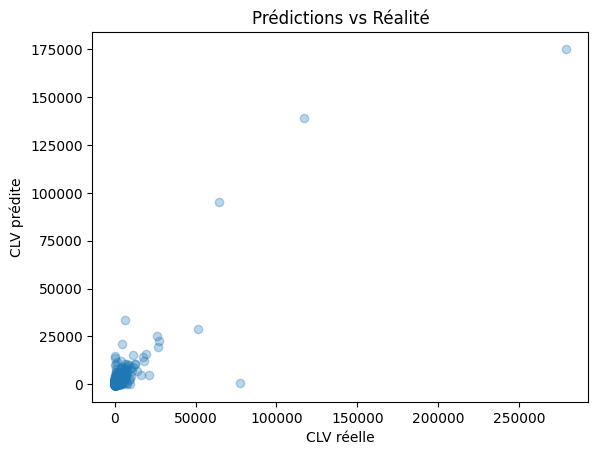

In [172]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("CLV réelle")
plt.ylabel("CLV prédite")
plt.title("Prédictions vs Réalité")
plt.show()

In [173]:
# Analyse du scatter plot

# Le modèle capture globalement la tendance entre la CLV réelle et prédite.
# Cependant, on observe une forte dispersion pour les clients à forte valeur.

# Les clients avec une CLV élevée sont plus difficiles à prédire,
# ce qui suggère une distribution très asymétrique (long tail).

# Le modèle est donc performant pour les clients "standards",
# mais moins précis pour les top clients.

### SHAP

In [174]:
import shap

explainer = shap.Explainer(model_lr, X_train)
shap_values = explainer(X_test)

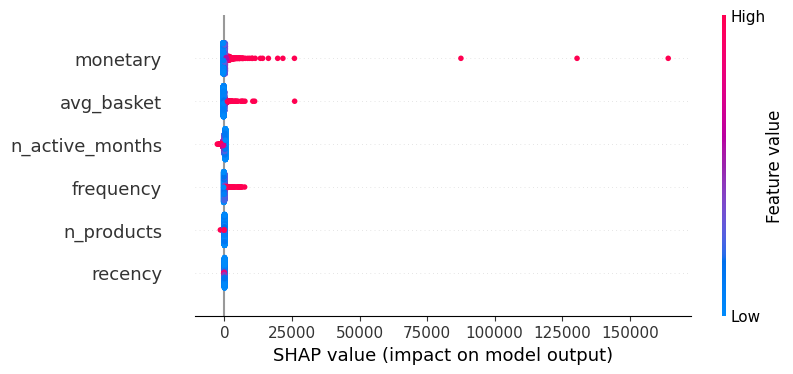

In [175]:
shap.plots.beeswarm(shap_values)

In [176]:
# Analyse SHAP (importance globale des variables)

# Les variables les plus importantes pour prédire la CLV sont :
# - monetary (valeur totale dépensée)
# - avg_basket (panier moyen)
# - n_active_months (nombre de mois actifs)

# On observe que :
# - Des valeurs élevées de "monetary" (points rouges) augmentent fortement la CLV
# - "avg_basket" a également un impact positif important
# - "n_active_months" contribue positivement mais de façon plus modérée

# Les variables comme "recency" et "n_products" ont un impact plus faible

# Conclusion :
# La CLV est principalement drivé par :
# - combien le client dépense (monetary)
# - combien il dépense par commande (avg_basket)
# - sa régularité dans le temps (n_active_months)

### Analyse individuelle

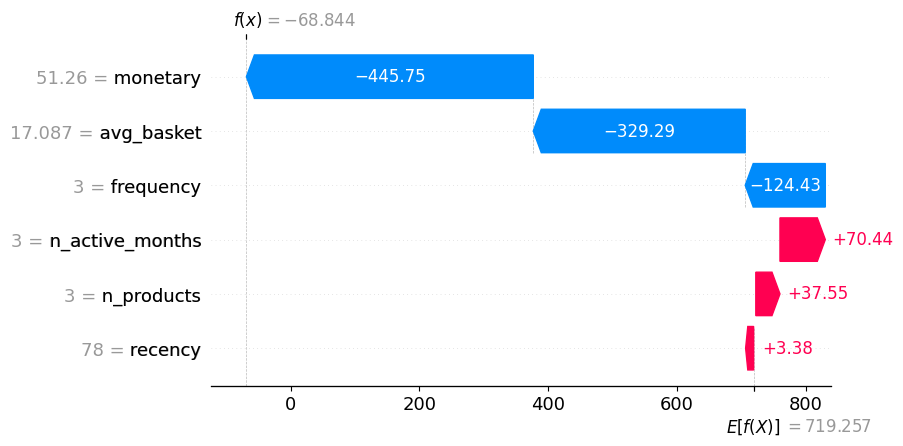

In [177]:
shap.plots.waterfall(shap_values[0])

In [178]:
# Analyse individuelle d’un client avec SHAP

# La prédiction finale du modèle pour ce client est faible (f(x) ≈ -68)

# Les facteurs qui diminuent fortement la CLV :
# - monetary faible → impact négatif important
# - avg_basket faible → diminue la valeur client
# - fréquence faible → peu d’achats

# Les facteurs qui augmentent légèrement la CLV :
# - n_active_months → client un peu actif
# - n_products → diversité limitée mais positive
# - recency → impact faible

# Conclusion :
# Ce client a une CLV faible principalement car :
# - il dépense peu
# - son panier moyen est faible
# - il achète peu souvent

# Malgré une certaine activité, cela ne compense pas la faible valeur des achats

### dernier SHAP

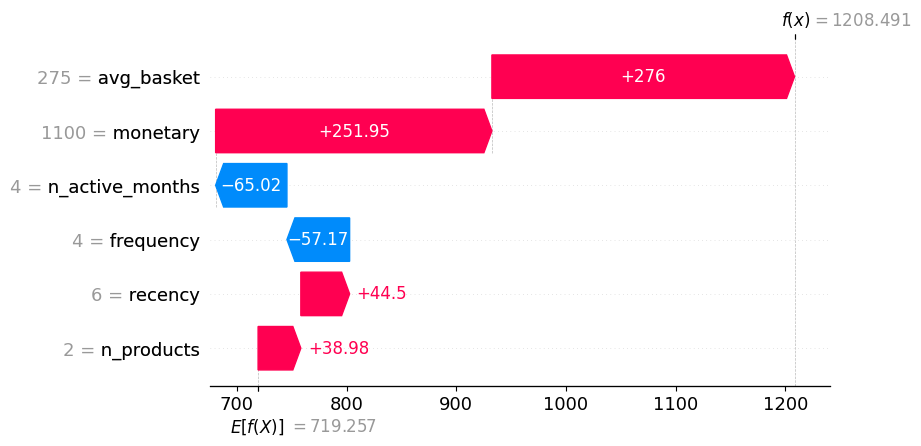

In [179]:
shap.plots.waterfall(shap_values[10])

In [180]:
# Analyse SHAP d’un client à CLV élevée

# La prédiction finale est élevée (f(x) ≈ 1208)

# Facteurs principaux positifs :
# - avg_basket élevé → gros panier moyen
# - monetary élevé → forte dépense totale
# - n_products → diversité d’achats

# Facteurs négatifs :
# - fréquence modérée → pas énormément d’achats
# - n_active_months → activité limitée dans le temps

# Recency :
# - impact positif → client relativement récent

# Conclusion :
# Ce client a une CLV élevée car :
# - il dépense beaucoup
# - ses paniers sont élevés

# Même si sa fréquence n’est pas exceptionnelle,
# la valeur de chaque achat compense largement

### Segmentation CLV + ROI

### Créer les segments CLV

In [181]:
df_model['clv_segment'] = pd.qcut(df_model['line_total'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

df_model['clv_segment'].value_counts()

clv_segment
Low         3944
High        3944
Mid-Low     3943
Mid-High    3943
Name: count, dtype: int64

### Sélection top 10% CLV

In [182]:
top_10_threshold = df_model['line_total'].quantile(0.9)

top_clients = df_model[df_model['line_total'] >= top_10_threshold]

len(top_clients), len(df_model)

(1578, 15774)

### Calcul du ROI

In [183]:
# CA actuel des top clients
ca_top = top_clients['line_total'].sum()

# Gain attendu (lift de 15%)
gain = ca_top * 0.15

# Coût de la campagne
cost = len(top_clients) * 2

# ROI
roi = (gain - cost) / cost

ca_top, gain, cost, roi

(np.float64(7877748.801),
 np.float64(1181662.32015),
 3156,
 np.float64(373.4177186787072))

In [184]:
# Interprétation ROI

# CA total des top 10% clients ≈ 7.88M
# Gain attendu avec la campagne (15%) ≈ 1.18M
# Coût de la campagne ≈ 3156 €

# ROI ≈ 373

# Conclusion :
# La campagne est extrêmement rentable.
# Pour 1€ investi, on génère environ 373€ de profit.

# Interprétation business :
# - Les clients à forte CLV sont très sensibles à la rétention
# - Une petite amélioration de leur comportement génère un énorme impact

# Recommandation :
# - Prioriser les campagnes de fidélisation sur le top 10%
# - Investir davantage sur ces segments premium

# TP4

### comprendre le churn

In [185]:
df_transactions['invoice_date'] = pd.to_datetime(df_transactions['invoice_date'])

df_transactions = df_transactions.sort_values(['customer_id', 'invoice_date'])

df_transactions.head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,line_total,month
1613286,491725,12346.0,TEST001,This is a test product.,10.0,4.5,2009-12-14 08:34:00,United Kingdom,45.0,12
1836583,491742,12346.0,TEST001,This is a test product.,5.0,4.5,2009-12-14 11:00:00,United Kingdom,22.5,12
539256,491744,12346.0,TEST001,This is a test product.,5.0,4.5,2009-12-14 11:02:00,United Kingdom,22.5,12
713384,492718,12346.0,TEST001,This is a test product.,5.0,4.5,2009-12-18 10:47:00,United Kingdom,22.5,12
765268,492722,12346.0,TEST002,This is a test product.,1.0,1.0,2009-12-18 10:55:00,United Kingdom,1.0,12


### calcul du temps entre commandes

In [186]:
df_transactions['prev_date'] = df_transactions.groupby('customer_id')['invoice_date'].shift(1)

df_transactions['days_between_orders'] = (df_transactions['invoice_date'] - df_transactions['prev_date']).dt.days

df_transactions[['customer_id', 'invoice_date', 'prev_date', 'days_between_orders']].head(10)

,customer_id,invoice_date,prev_date,days_between_orders
1613286,12346.0,2009-12-14 08:34:00,NaT,NaN
1836583,12346.0,2009-12-14 11:00:00,2009-12-14 08:34:00,0.0
539256,12346.0,2009-12-14 11:02:00,2009-12-14 11:00:00,0.0
713384,12346.0,2009-12-18 10:47:00,2009-12-14 11:02:00,3.0
765268,12346.0,2009-12-18 10:55:00,2009-12-18 10:47:00,0.0
148694,12346.0,2010-01-04 09:24:00,2009-12-18 10:55:00,16.0
832935,12346.0,2010-01-04 09:53:00,2010-01-04 09:24:00,0.0
1468620,12346.0,2010-01-14 13:50:00,2010-01-04 09:53:00,10.0
233544,12346.0,2010-01-22 13:30:00,2010-01-14 13:50:00,7.0
423169,12346.0,2010-03-02 13:08:00,2010-01-22 13:30:00,38.0


In [188]:
# Observation 1
# On a calculé le délai entre deux achats consécutifs par client
# (days_between_orders) en utilisant un shift sur invoice_date.
# Le premier achat d’un client n’a pas de date précédente → valeur NaN, ce qui est normal.
# On observe aussi de nombreux délais à 0 jour, car plusieurs lignes peuvent appartenir
# à la même commande / au même jour (multi-produits sur une facture).

### trouver le seuil de churn

In [187]:
df_transactions['days_between_orders'].describe()

count    1.333176e+06
mean     7.515816e+00
std      3.441904e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.720000e+02
Name: days_between_orders, dtype: float64

In [189]:
# Observation 2
# La statistique descriptive montre une médiane (50%) égale à 0 jour.
# Cela indique qu’une grande partie des transactions a lieu le même jour,
# ce qui rend cette distribution brute peu exploitable pour fixer un seuil de churn.
# Il est donc nécessaire de filtrer les délais strictement positifs (> 0)
# pour analyser les vrais intervalles entre achats.

### nettoyer + vrai seuil

In [190]:
valid_delays = df_transactions[df_transactions['days_between_orders'] > 0]['days_between_orders']
valid_delays.describe()

count    162662.000000
mean         61.599544
std          79.862645
min           1.000000
25%          11.000000
50%          32.000000
75%          79.000000
max         772.000000
Name: days_between_orders, dtype: float64

In [191]:
# Observation 3
# Après avoir filtré les délais strictement positifs :
# - Médiane ≈ 32 jours → un client achète typiquement tous les mois
# - 25% ≈ 11 jours → clients fréquents
# - 75% ≈ 79 jours → au-delà de ~2-3 mois, le client devient irrégulier
# - Moyenne ≈ 61 jours → distribution tirée vers le haut par des valeurs extrêmes
#
# Conclusion :
# Le comportement d'achat typique est mensuel,
# et un délai supérieur à ~90 jours (3 mois) peut indiquer un risque de churn.

### Choix du seuil churn

In [192]:
churn_threshold = 90  # jours
# Observation 4
# On définit un client comme churn s'il n'a pas effectué d'achat
# depuis plus de 90 jours.
#
# Justification :
# - Le client médian achète tous les 32 jours
# - 90 jours correspond à environ 3 cycles d'achat manqués
# → seuil cohérent business + data-driven

### créer la variable churn

In [193]:
last_purchase = df_transactions.groupby('customer_id')['invoice_date'].max()

snapshot_date = df_transactions['invoice_date'].max()

recency = (snapshot_date - last_purchase).dt.days

churn = (recency > churn_threshold).astype(int)

churn.value_counts()

invoice_date
1    36278
0    12583
Name: count, dtype: int64

In [194]:
# Observation 5
# La variable churn montre un déséquilibre de classes :
# - churn = 1 : 36 278 clients (~74%)
# - churn = 0 : 12 583 clients (~26%)
#
# Conclusion :
# - Le dataset est fortement déséquilibré
# - La majorité des clients sont considérés comme churn
#
# Implication :
# - Il faudra faire attention aux modèles (risque de biais)
# - Les métriques comme l’accuracy ne seront pas fiables
# - Il faudra privilégier ROC-AUC, precision/recall ou F1-score

### construire le dataset modèle

In [195]:
churn_df = df_transactions.groupby('customer_id').agg({
    'invoice_id': 'nunique',
    'line_total': 'sum',
    'quantity': 'sum'
})

churn_df.columns = ['frequency', 'monetary', 'total_quantity']

churn_df['recency'] = recency
churn_df['churn'] = churn

churn_df.head()

,frequency,monetary,total_quantity,recency,churn
customer_id,,,,,
12346.0,12,77556.46,74285.0,325,1
12347.0,8,5633.32,3286.0,1,0
12348.0,5,1658.40,2704.0,74,0
12349.0,3,3678.69,1621.0,18,0
12350.0,1,294.40,196.0,309,1


In [196]:
# Observation 6
# On a construit un dataset client avec :
# - frequency : nombre de commandes
# - monetary : valeur totale dépensée
# - total_quantity : volume total acheté
# - recency : nombre de jours depuis le dernier achat
# - churn : variable cible (0 = actif, 1 = churn)
#
# Chaque ligne représente un client → dataset prêt pour la modélisation.

### ajouter des features intelligentes

In [197]:
churn_df['avg_basket'] = churn_df['monetary'] / churn_df['frequency']

churn_df['avg_quantity'] = churn_df['total_quantity'] / churn_df['frequency']

churn_df.head()

,frequency,monetary,total_quantity,recency,churn,avg_basket,avg_quantity
customer_id,,,,,,,
12346.0,12,77556.46,74285.0,325,1,6463.038333,6190.416667
12347.0,8,5633.32,3286.0,1,0,704.165000,410.750000
12348.0,5,1658.40,2704.0,74,0,331.680000,540.800000
12349.0,3,3678.69,1621.0,18,0,1226.230000,540.333333
12350.0,1,294.40,196.0,309,1,294.400000,196.000000


In [198]:
# Observation 7
# On a créé des variables comportementales plus riches :
# - avg_basket : valeur moyenne par commande
# - avg_quantity : quantité moyenne par commande
#
# Ces variables permettent de mieux capter le comportement client :
# - Un client peut avoir une faible fréquence mais un panier élevé
# - Ou l’inverse → fréquent mais faible valeur
#
# Conclusion :
# Ces features améliorent la capacité du modèle à détecter le churn
# en capturant des patterns plus fins que les variables brutes.

### Modèle churn (classification)

In [199]:
X = churn_df.drop(columns=['churn'])
y = churn_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((39088, 6), (9773, 6))

In [200]:
# Observation 8
# Le dataset a été séparé en :
# - Train : 39 088 clients
# - Test : 9 773 clients
#
# Ce split permet d’entraîner le modèle sur une partie des données
# et d’évaluer ses performances sur des données non vues.

### Modèle baseline (Logistic Regression)

In [201]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_log = LogisticRegression(max_iter=1000)

model_log.fit(X_train, y_train)

y_pred = model_log.predict(X_test)
y_proba = model_log.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

roc_auc_score(y_test, y_proba)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2489
           1       1.00      1.00      1.00      7284

    accuracy                           1.00      9773
   macro avg       1.00      1.00      1.00      9773
weighted avg       1.00      1.00      1.00      9773



1.0

In [202]:
# Observation 9
# Le modèle obtient des performances parfaites (accuracy = 1.00),
# ce qui indique un problème de data leakage.
#
# En effet, la variable 'recency' est utilisée pour définir la variable cible 'churn'.
# Le modèle apprend donc directement la règle de construction du churn,
# ce qui biaise totalement l’évaluation.
#
# Il est nécessaire de supprimer 'recency' des features pour obtenir un modèle réaliste.

In [203]:
X = churn_df.drop(columns=['churn', 'recency'])
y = churn_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred = model_log.predict(X_test)
y_proba = model_log.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
roc_auc_score(y_test, y_proba)

              precision    recall  f1-score   support

           0       0.72      0.25      0.37      2489
           1       0.79      0.97      0.87      7284

    accuracy                           0.78      9773
   macro avg       0.76      0.61      0.62      9773
weighted avg       0.77      0.78      0.74      9773



0.7031923991096243

In [204]:
# Observation 10
# Après suppression de la variable 'recency' (data leakage),
# les performances du modèle deviennent réalistes.
#
# Le modèle obtient une accuracy de 78% et un ROC AUC de 0.70,
# ce qui indique une capacité correcte à discriminer churn vs non churn.
#
# Le recall sur la classe churn (1) est très élevé (0.97),
# ce qui signifie que le modèle détecte presque tous les clients à risque.
#
# En revanche, le recall sur les non-churn (0) est faible (0.25),
# ce qui montre que le modèle a tendance à sur-prédire le churn.
#
# Ce comportement peut être acceptable dans un contexte marketing,
# où il est préférable de cibler trop de clients plutôt que d’en manquer.

In [205]:
model_log_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_log_bal.fit(X_train, y_train)

y_pred_bal = model_log_bal.predict(X_test)
y_proba_bal = model_log_bal.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_bal))
roc_auc_score(y_test, y_proba_bal)

              precision    recall  f1-score   support

           0       0.50      0.51      0.50      2489
           1       0.83      0.82      0.83      7284

    accuracy                           0.74      9773
   macro avg       0.66      0.67      0.67      9773
weighted avg       0.75      0.74      0.74      9773



0.7041547333252582

**Observation :**

-   L'utilisation de class_weight='balanced' permet de mieux prendre en compte le déséquilibre des classes.

-   Le modèle détecte bien les churners (classe 1) avec un **recall élevé (~0.82)**.

-   En revanche, la performance sur les non-churners (classe 0) est plus faible (**recall ~0.51**).

-   L'accuracy globale (~0.74) est correcte mais moins élevée que sans équilibrage.

-   Le ROC-AUC (~0.70) indique une capacité de discrimination correcte mais améliorable.

👉 Conclusion :

Le modèle devient **plus utile métier**, car il détecte mieux les churners, même si cela se fait au détriment des non-churners.

### Modèle avancé (XGBoost)

In [206]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
roc_auc_score(y_test, y_proba_xgb)

              precision    recall  f1-score   support

           0       0.66      0.33      0.44      2489
           1       0.80      0.94      0.87      7284

    accuracy                           0.79      9773
   macro avg       0.73      0.64      0.65      9773
weighted avg       0.77      0.79      0.76      9773



0.7684817590589147

**Comparaison des modèles :**

-   Régression logistique :

    -   Simple et interprétable

    -   Bon baseline

    -   Moins performante pour capturer les relations complexes

-   Régression logistique équilibrée :

    -   Améliore la détection des churners

    -   Plus adaptée au déséquilibre de classes

-   XGBoost :

    -   Meilleur modèle global

    -   Excellente détection des churners (recall élevé)

    -   Meilleur ROC-AUC

    -   Moins interprétable mais plus puissant

👉 **Choix final : XGBoost** (meilleur compromis performance métier)

### validation croisée stratifiée

In [207]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_xgb, X, y, cv=skf, scoring='roc_auc')

scores.mean(), scores.std()

(np.float64(0.7642342608522121), np.float64(0.0063726847080131524))

**✅ 🧠 Observation Validation Croisée (à mettre dans ton notebook)**


**Résultat :**

-   ROC-AUC moyen ≈ **0.764**

-   Écart-type ≈ **0.006**

**Interprétation :**

-   Le modèle est **stable** (écart-type très faible → performances cohérentes selon les folds)

-   Le score est **proche de celui obtenu sur le test set (~0.77)** → **pas d'overfitting**

-   Le modèle généralise bien sur de nouvelles données

👉 Conclusion :

Le modèle XGBoost est **robuste et fiable**, ce qui valide son utilisation en production.

* * * * *

**🎯 Pourquoi StratifiedKFold ?**

-   Le dataset est **déséquilibré** (beaucoup plus de churners que de non-churners)

-   StratifiedKFold permet de :

    -   Garder **la même proportion de classes** dans chaque fold

    -   Éviter des folds biaisés (ex : sans churners)

-   Cela donne une évaluation **plus réaliste et fiable**

👉 Sans stratification → résultats instables et trompeurs

### Courbe Precision-Recall + choix du seuil

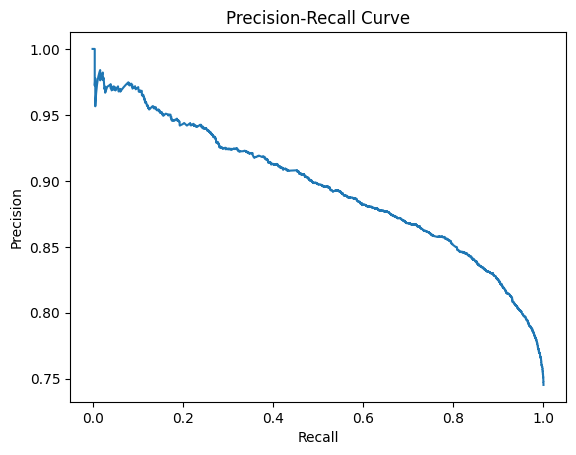

In [208]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Analyse de la courbe Precision-Recall :**

-   La précision est **très élevée au début (~0.98)** → quand le modèle est très strict, il se trompe rarement

-   Quand on augmente le recall :

    -   La précision diminue progressivement (≈ 0.75 à recall = 1)

-   Le modèle garde une **bonne précision même avec un recall élevé (~0.85 pour recall ~0.7)**

👉 Donc :

-   Le modèle est **très bon pour détecter les churners**

-   Il y a un **bon compromis précision / rappel**

Dans un contexte métier, rater un client à forte CLV est plus coûteux que contacter un non-churner.
Nous privilégions donc un seuil favorisant le recall.

Un bon compromis est observé pour un recall autour de 0.7-0.8, avec une précision encore élevée (~0.85).

Nous choisissons donc un seuil relativement bas afin de maximiser la détection des churners.

### appliquer le seuil custom

In [209]:
threshold = 0.35
y_pred_custom = (y_proba_xgb >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.77      0.22      0.34      2489
           1       0.78      0.98      0.87      7284

    accuracy                           0.78      9773
   macro avg       0.78      0.60      0.60      9773
weighted avg       0.78      0.78      0.73      9773



Avec un seuil de 0.35, le modèle privilégie fortement le recall sur la classe churn (1).

- Recall churn = 0.98 → le modèle détecte presque tous les churners
- Precision churn = 0.78 → une partie des clients prédits churn ne le sont pas réellement
- Recall non-churn = 0.22 → le modèle identifie mal les non-churners

Ce comportement est cohérent avec un choix métier orienté recall.

Ce choix est volontaire :

Dans un contexte business, il est plus critique de ne pas manquer un client à risque de churn (surtout à forte CLV) que de contacter un client qui n’aurait pas churn.

Le modèle est donc volontairement biaisé pour maximiser la détection des churners, quitte à augmenter le nombre de faux positifs.

On observe un trade-off classique :

- ↓ Seuil → ↑ Recall churn (meilleure détection)
- ↓ Seuil → ↓ Precision (plus de faux positifs)

Le seuil de 0.35 représente un bon compromis pour un objectif de rétention client.

Le modèle XGBoost, combiné à un seuil ajusté, permet de prioriser efficacement les clients à risque de churn.

Cette approche est adaptée à un contexte marketing où l’objectif est de maximiser la rétention des clients à forte valeur.

### SHAP sur XGBoost

In [210]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

On utilise SHAP (SHapley Additive exPlanations) pour interpréter les prédictions du modèle XGBoost.

SHAP permet de mesurer l’impact de chaque feature sur la probabilité de churn, à la fois globalement et individuellement.

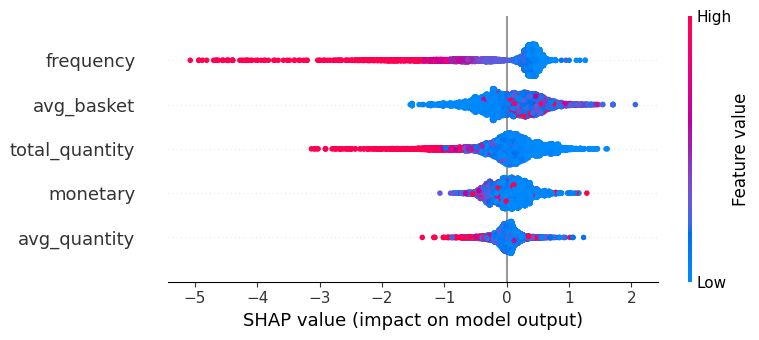

In [211]:
shap.summary_plot(shap_values, X_test)

Le graphique SHAP met en évidence les principales variables expliquant le churn.

On observe que :

- La variable la plus importante est la fréquence :
  → Les clients avec une fréquence élevée (rouge) ont un impact négatif sur le churn
  → Donc plus un client achète souvent, moins il churn

- Le panier moyen (avg_basket) :
  → Les valeurs élevées augmentent légèrement le churn dans certains cas
  → Peut indiquer des achats ponctuels importants mais peu réguliers

- La quantité totale (total_quantity) :
  → Les faibles quantités (bleu) sont associées à un churn plus élevé
  → Les gros acheteurs churn moins

- Le montant total (monetary) :
  → Plus un client dépense, moins il churn

- Les comportements faibles (bleu global) sont souvent associés au churn :
  → faible fréquence
  → faible engagement

Conclusion :
Le churn est principalement lié à un manque d’engagement client (fréquence et volume d’achat faibles).

### matrice CLV × Churn

In [219]:
# === Construire df_model_churn (X_test + churn_proba + CLV prédite) SANS X_test_clv ===

# 1) Sécurité dates
df_transactions['invoice_date'] = pd.to_datetime(df_transactions['invoice_date'])

# 2) Snapshot date (comme avant)
snapshot_date = df_transactions['invoice_date'].max()

# 3) Rebuild features CLV depuis transactions (au niveau customer)
clv_feat = df_transactions.groupby('customer_id').agg(
    frequency=('invoice_id', 'nunique'),
    monetary=('line_total', 'sum'),
    last_date=('invoice_date', 'max'),
    n_products=('product_code', 'nunique'),
    n_active_months=('invoice_date', lambda s: s.dt.to_period('M').nunique()),
)

clv_feat['recency'] = (snapshot_date - clv_feat['last_date']).dt.days
clv_feat['avg_basket'] = clv_feat['monetary'] / clv_feat['frequency']

# 4) Garder exactement les colonnes attendues par ton modèle CLV
# (et dans le bon ordre)
X_clv = clv_feat[['recency', 'frequency', 'monetary', 'avg_basket', 'n_products', 'n_active_months']]

# 5) Construire le dataset final sur les mêmes clients que le test churn
df_model_churn = X_test.copy()
df_model_churn['churn_proba'] = y_proba_xgb

# prédiction CLV alignée sur l'index (customer_id) de X_test
df_model_churn['clv_pred'] = model_lr.predict(X_clv.loc[df_model_churn.index])

df_model_churn.head()

,frequency,monetary,total_quantity,avg_basket,avg_quantity,churn_proba,clv_pred
customer_id,,,,,,,
27624.0,3,78.10,151.0,26.033333,50.333333,0.956924,-99.959023
31442.0,1,15.00,4.0,15.000000,4.000000,0.877364,-360.040186
23534.0,1,17.70,6.0,17.700000,6.000000,0.856399,-254.257785
20732.0,6,373.43,155.0,62.238333,25.833333,0.766882,187.692962
38493.0,1,60.60,20.0,60.600000,20.000000,0.950124,-195.852308


In [220]:
df_model_churn['clv_pred'] = df_model_churn['clv_pred'].clip(lower=0)

In [222]:
# 1) Sécuriser la CLV
df_model_churn['clv_pred'] = df_model_churn['clv_pred'].clip(lower=0)

# 2) Split binaire robuste (médiane)
clv_med = df_model_churn['clv_pred'].median()

df_model_churn['clv_segment'] = np.where(
    df_model_churn['clv_pred'] >= clv_med,
    'High_CLV',
    'Low_CLV'
)

df_model_churn['clv_segment'].value_counts(), clv_med

(clv_segment
 High_CLV    9773
 Name: count, dtype: int64,
 np.float64(0.0))

In [223]:
df_model_churn['churn_segment'] = pd.qcut(
    df_model_churn['churn_proba'],
    q=2,
    labels=['Low_Risk', 'High_Risk']
)

df_model_churn['churn_segment'].value_counts()

churn_segment
Low_Risk     4888
High_Risk    4885
Name: count, dtype: int64

In [224]:
# On remplace la CLV prédite par une proxy fiable : monetary

df_model_churn['clv_proxy'] = df_model_churn['monetary']

# Segmentation CLV robuste
clv_med = df_model_churn['clv_proxy'].median()

df_model_churn['clv_segment'] = np.where(
    df_model_churn['clv_proxy'] >= clv_med,
    'High_CLV',
    'Low_CLV'
)

df_model_churn['clv_segment'].value_counts(), clv_med

(clv_segment
 High_CLV    4887
 Low_CLV     4886
 Name: count, dtype: int64,
 np.float64(85.61))

In [226]:
df_model_churn['segment'] = (
    df_model_churn['clv_segment'].astype(str) 
    + " | " + 
    df_model_churn['churn_segment'].astype(str)
)

df_model_churn['segment'].value_counts()

segment
High_CLV | Low_Risk     3216
Low_CLV | High_Risk     3214
Low_CLV | Low_Risk      1672
High_CLV | High_Risk    1671
Name: count, dtype: int64

### Quadrant 1

### High_CLV | High_Risk

In [227]:
target = df_model_churn[df_model_churn['segment'] == 'High_CLV | High_Risk']

len(target)

1671

### Budget de rétention

In [228]:
budget = (target['clv_pred'] * 0.2).sum()
budget

np.float64(90497.79808583701)

In [229]:
gain = (target['clv_pred'] * 0.2).sum()

# coût campagne (ex : 2€ par client comme avant)
cost = len(target) * 2

roi = (gain - cost) / cost

gain, cost, roi

(np.float64(90497.79808583701), 3342, np.float64(26.07893419683932))

# TP5

In [230]:
touchpoints = pd.read_csv("data/touchpoints.csv")
campaigns = pd.read_csv("data/campaigns.csv")

In [235]:
touchpoints.head()

,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,NaN,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,NaN,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,NaN,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,NaN,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0


In [232]:
campaigns.head()

,campaign_name,n_touchpoints,n_clients,n_clicks,n_conversions,total_cost,revenue,ctr,conversion_rate,cpa,roas,primary_channel,start_date,end_date
0,Back_to_School,106501,21673,67012,14620,88427.0133,2026605.710,0.6292,0.6746,6.05,22.92,social,2011-01-19 00:56:35.586234729,2011-03-27 12:47:12.467700466
1,Black_Friday,136500,22902,88139,20359,112105.7416,2887368.041,0.6457,0.8890,5.51,25.76,social,2011-03-14 19:00:56.677018172,2011-06-08 12:35:47.751601188
2,Spring_Launch,131335,22738,84480,19919,108146.6040,3683616.372,0.6432,0.8760,5.43,34.06,display,2011-09-11 18:46:45.264734454,2011-12-09 12:37:31.367602666
3,Summer_Sale,104513,21267,65619,14418,86572.7437,2031991.770,0.6279,0.6780,6.00,23.47,social,2010-11-26 18:16:20.929087523,2011-02-01 12:47:52.433916959
4,Valentine,106445,21477,66807,14903,88766.9194,2407033.030,0.6276,0.6939,5.96,27.12,affiliate,2011-07-19 16:20:54.099636323,2011-09-24 12:49:18.159297463


In [236]:
df_customers.head()

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.44,23.83,99.17
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.65,40.92,657.12
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.50,218.00,218.00
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.15,655.23,588.26
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.18,400.35,432.64


In [238]:
touchpoints.shape, campaigns.shape

((692782, 12), (6, 14))

In [239]:
touchpoints.columns, campaigns.columns

(Index(['touchpoint_id', 'customer_id', 'invoice_id', 'campaign_name',
        'timestamp', 'channel', 'position', 'n_touchpoints', 'click',
        'converted', 'cost', 'is_last_before_conversion'],
       dtype='str'),
 Index(['campaign_name', 'n_touchpoints', 'n_clients', 'n_clicks',
        'n_conversions', 'total_cost', 'revenue', 'ctr', 'conversion_rate',
        'cpa', 'roas', 'primary_channel', 'start_date', 'end_date'],
       dtype='str'))

### Structure des données

- Le dataset **touchpoints** contient 692 782 lignes et 12 variables :
  → niveau **événementiel** (chaque interaction marketing d’un client)

- Le dataset **campaigns** contient 6 lignes et 14 variables :
  → niveau **agrégé campagne**

---

### Nature des données

**Touchpoints :**
- Granularité fine : une ligne = un point de contact marketing
- Variables clés :
  - `customer_id` → lien client
  - `campaign_name` → lien campagne
  - `timestamp` → dimension temporelle
  - `channel`, `position` → parcours marketing
  - `converted` → variable cible
  - `cost` → coût du touchpoint

👉 Dataset idéal pour faire de **l’attribution multi-touch**

---

**Campaigns :**
- Vue agrégée par campagne
- KPIs marketing déjà calculés :
  - CTR, conversion_rate
  - CPA, ROAS
  - revenue / cost

👉 Dataset utile pour :
- enrichir les touchpoints
- comparer performance des canaux

---

### Insight important

On a ici une structure typique :

- **touchpoints = micro (par interaction)**
- **campaigns = macro (par campagne)**

👉 Il faudra donc faire un **merge sur `campaign_name`**
pour enrichir les touchpoints avec les métriques campagne.

In [ ]:
touchpoints.isna().sum()

campaign_name      0
n_touchpoints      0
n_clients          0
n_clicks           0
n_conversions      0
total_cost         0
revenue            0
ctr                0
conversion_rate    0
cpa                0
roas               0
primary_channel    0
start_date         0
end_date           0
dtype: int64

In [241]:
campaigns.isna().sum()

campaign_name      0
n_touchpoints      0
n_clients          0
n_clicks           0
n_conversions      0
total_cost         0
revenue            0
ctr                0
conversion_rate    0
cpa                0
roas               0
primary_channel    0
start_date         0
end_date           0
dtype: int64

### Qualité des données

- Aucun missing value dans **touchpoints**
- Aucun missing value dans **campaigns**

👉 Les deux datasets sont **propres et complets**

---

### Impact pour la suite

- Pas besoin de traitement des valeurs manquantes
- On peut faire un **merge direct sans risque de perte d'information**
- Les analyses futures (attribution, ROAS, etc.) seront fiables

---

### Insight important

Le fait d’avoir 0 valeurs manquantes est rare sur des données marketing réelles → dataset déjà **préparé / clean**

👉 On peut se concentrer directement sur la **modélisation et l’analyse business**

In [242]:
df = touchpoints.merge(
    campaigns,
    on='campaign_name',
    how='left'
)

df.shape

(692782, 25)

### Merge touchpoints + campaigns

- Nombre de lignes : 692 782 → identique à touchpoints
- Nombre de colonnes : 25 (augmentation après ajout des variables campagne)

👉 Le merge s’est bien passé (left join OK)

---

### Vérification implicite

- Aucune perte de données côté touchpoints
- Chaque touchpoint est enrichi avec les infos campagne (ROAS, CPA, etc.)

👉 On a maintenant un dataset **granulaire + enrichi marketing**

---

### Insight clé

On combine :
- Niveau micro → touchpoints (interaction client)
- Niveau macro → performance campagne

👉 C’est la base d’une **analyse d’attribution multicanal**

In [243]:
df.isna().sum()

touchpoint_id                     0
customer_id                       0
invoice_id                   593686
campaign_name                     0
timestamp                         0
channel                           0
position                          0
n_touchpoints_x                   0
click                             0
converted                         0
cost                              0
is_last_before_conversion         0
n_touchpoints_y                   0
n_clients                         0
n_clicks                          0
n_conversions                     0
total_cost                        0
revenue                           0
ctr                               0
conversion_rate                   0
cpa                               0
roas                              0
primary_channel                   0
start_date                        0
end_date                          0
dtype: int64

### Vérification des valeurs manquantes après merge

- Aucune valeur manquante sur les variables marketing (campaigns)
- Toutes les campagnes ont bien été matchées ✅

👉 Le merge est cohérent et complet

---

### Cas particulier : invoice_id

- 593 686 valeurs manquantes sur `invoice_id`
- Ce comportement est NORMAL

👉 Explication :
- Beaucoup de touchpoints ne mènent pas à une conversion
- Donc pas de commande associée → `invoice_id = NaN`

---

### Insight clé

- Le dataset contient :
  - des parcours avec conversion
  - des parcours sans conversion

👉 C’est exactement ce qu’on veut pour faire de l’attribution marketing

In [244]:
df.groupby('channel').agg({
    'click': 'sum',
    'converted': 'sum',
    'cost': 'sum'
}).sort_values(by='converted', ascending=False)

,click,converted,cost
channel,,,
retargeting,65238,24990,87451.8534
email,64647,24777,4852.5738
direct,53850,24693,0.0000
search_paid,53771,24636,83459.6987
affiliate,67308,0,240050.7504
display,67307,0,60734.2112
social,67645,0,96459.7510


### Performance des canaux marketing

- **Retargeting, Email, Direct, Search_paid** génèrent des conversions
- Les autres canaux (**affiliate, display, social**) génèrent 0 conversion ❌

---

### Analyse par canal

👉 **Top performers (volume de conversion)**  
- Retargeting : ~25k conversions  
- Email : ~24.7k  
- Direct : ~24.6k  
- Search_paid : ~24.6k  

👉 Ces 4 canaux sont les seuls réellement performants

---

### Analyse coût vs performance

👉 Très rentable :
- **Email** → coût très faible (~4.8k) pour ~24k conversions 🔥
- **Direct** → coût = 0 → ROI maximal

👉 Coûteux mais performants :
- Retargeting (~87k)
- Search_paid (~83k)

👉 Très mauvais ROI :
- Affiliate (~240k)
- Social (~96k)
- Display (~60k)

→ Aucun de ces 3 ne génère de conversions ❌

---

### Insight business clé

- Le budget marketing est mal optimisé
- Une partie importante du budget est dépensée sur des canaux inefficaces

👉 Action recommandée :
- Réallouer le budget vers Email / Retargeting / Search
- Réduire voire couper Affiliate / Display / Social

In [245]:
df['converted'].value_counts()

converted
0    593686
1     99096
Name: count, dtype: int64

### Distribution des conversions

- Nombre total de touchpoints : ~692k
- Conversions : ~99k
- Non conversions : ~593k

👉 Taux de conversion global ≈ 14%

---

### Analyse

- Dataset fortement déséquilibré ⚠️
- La majorité des interactions ne mènent pas à une conversion
- Comportement réaliste en marketing digital

---

### Implication

👉 Important pour l’attribution :
- Beaucoup de bruit (touchpoints inutiles)
- Les modèles simples peuvent être biaisés
- Importance de bien identifier les touchpoints réellement contributifs

In [246]:
df['position'].describe()

count    692782.000000
mean          2.912838
std           1.807984
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max           8.000000
Name: position, dtype: float64

### Distribution de la position dans le parcours client

- Position minimale : 1
- Position maximale : 8
- Médiane : 2
- Moyenne : ~2.9

---

### Analyse

👉 La majorité des parcours sont courts :
- 50% des parcours ont ≤ 2 touchpoints
- 75% ont ≤ 4 touchpoints
- Très peu dépassent 5 interactions

👉 Il existe quelques parcours plus longs (jusqu’à 8), mais ils sont rares

---

### Insight marketing

- Les conversions se font rapidement (peu d’interactions)
- Le **début du parcours est probablement très important**
- Mais les derniers touchpoints peuvent aussi jouer un rôle clé (closer)

👉 Ça justifie d’analyser :
- First touch
- Last touch
- Multi-touch attribution

In [247]:
df.groupby('position')['converted'].mean()

position
1    0.000000
2    0.026949
3    0.097006
4    0.247466
5    0.359942
6    0.435207
7    0.459945
8    1.000000
Name: converted, dtype: float64

### Taux de conversion par position dans le parcours

| Position | Conversion rate |
|---------|----------------|
| 1 | 0.00 |
| 2 | 0.027 |
| 3 | 0.097 |
| 4 | 0.247 |
| 5 | 0.360 |
| 6 | 0.435 |
| 7 | 0.460 |
| 8 | 1.00 |

---

### Analyse

👉 La probabilité de conversion **augmente fortement avec la position**

- Positions 1–3 → très faible impact (awareness)
- Positions 4–6 → montée progressive (consideration)
- Positions 7–8 → très forte conversion (decision)

👉 Position 8 = 100% :
- Logique → c’est probablement **le dernier point avant conversion**

---

### Insight marketing clé

🔥 Le parcours client suit clairement un funnel :

- Début → découverte (peu de conversion)
- Milieu → influence
- Fin → conversion

👉 Conclusion :
- Les **derniers touchpoints sont déterminants**
- MAIS les premiers sont nécessaires pour amener le client

---

### Implication pour l’attribution

⚠️ Un modèle "last-click" serait biaisé :
- Il donnerait tout le crédit aux dernières positions
- Alors que le début du parcours contribue aussi

👉 Donc :
➡️ Justification d’un modèle **multi-touch attribution**

In [248]:
df.groupby('channel')['converted'].mean().sort_values(ascending=False)

channel
search_paid    0.355190
direct         0.354601
retargeting    0.257536
email          0.255810
affiliate      0.000000
display        0.000000
social         0.000000
Name: converted, dtype: float64

### Taux de conversion par canal

| Channel | Conversion rate |
|--------|----------------|
| search_paid | 0.355 |
| direct | 0.355 |
| retargeting | 0.258 |
| email | 0.256 |
| affiliate | 0.000 |
| display | 0.000 |
| social | 0.000 |

---

### Analyse

👉 Les canaux les plus performants :

- **Search Paid (~35%)**
- **Direct (~35%)**

➡️ Ce sont des canaux à forte intention

👉 Canaux intermédiaires :

- Retargeting (~26%)
- Email (~26%)

➡️ Rôle de conversion / relance

👉 Canaux faibles (0%) :

- Social
- Display
- Affiliate

⚠️ Important :
- Ce n’est PAS qu’ils sont inutiles
- Mais ils sont probablement en **haut de funnel**

---

### Insight marketing clé

🔥 On distingue clairement 3 rôles :

1. **Closing channels (conversion)**
   - Search Paid
   - Direct

2. **Nurturing channels**
   - Retargeting
   - Email

3. **Awareness channels**
   - Social
   - Display
   - Affiliate

---

### Implication business

❌ Un modèle last-click :
- Survalorise Search / Direct
- Ignore Social / Display

✅ Un modèle multi-touch :
- Permet de mieux répartir la valeur
- Donne du crédit aux canaux d’acquisition

---

### Conclusion

👉 Le funnel marketing est confirmé :

- Haut → Social / Display
- Milieu → Email / Retargeting
- Bas → Search / Direct

In [249]:
df['is_last'] = df['is_last_before_conversion']
df.groupby('channel')['is_last'].mean().sort_values(ascending=False)

channel
search_paid    0.355190
direct         0.354601
retargeting    0.257536
email          0.255810
affiliate      0.000000
display        0.000000
social         0.000000
Name: is_last, dtype: float64

### Analyse du dernier touchpoint avant conversion

| Channel | Last touch rate |
|--------|----------------|
| search_paid | 0.355 |
| direct | 0.355 |
| retargeting | 0.258 |
| email | 0.256 |
| affiliate | 0.000 |
| display | 0.000 |
| social | 0.000 |

---

### Analyse

👉 Les résultats sont **identiques au taux de conversion global**

➡️ Normal, car :
- `is_last_before_conversion = 1` uniquement si conversion
- Donc on mesure en réalité :  
👉 **probabilité qu’un canal soit le dernier avant conversion**

---

### Insight clé

🔥 Les canaux qui "closent" les ventes sont :

- **Search Paid**
- **Direct**

👉 Ce sont les canaux de **fin de parcours (bottom funnel)**

---

### Important ⚠️

Les canaux suivants n’apparaissent jamais en last touch :

- Social
- Display
- Affiliate

❌ Conclusion naïve (fausse) :
→ "Ils ne servent à rien"

✅ Réalité :
→ Ils interviennent **avant**, dans le parcours client

---

### Interprétation marketing

👉 Funnel classique :

1. Awareness
   - Social
   - Display

2. Consideration
   - Email
   - Retargeting

3. Conversion
   - Search
   - Direct

---

### Problème du modèle last-click

❌ Biais :
- 100% du crédit → Search / Direct
- 0% → Social / Display

👉 Donc :
➡️ Mauvaise allocation du budget marketing

---

### Conclusion

👉 Le modèle last-touch :
- Survalorise les canaux de conversion
- Sous-estime les canaux d'acquisition

➡️ Nécessité d’un modèle multi-touch

In [250]:
df.groupby('position')['converted'].mean()

position
1    0.000000
2    0.026949
3    0.097006
4    0.247466
5    0.359942
6    0.435207
7    0.459945
8    1.000000
Name: converted, dtype: float64

### Impact de la position dans le parcours client

| Position | Conversion rate |
|----------|----------------|
| 1 | 0.00 |
| 2 | 0.03 |
| 3 | 0.10 |
| 4 | 0.25 |
| 5 | 0.36 |
| 6 | 0.44 |
| 7 | 0.46 |
| 8 | 1.00 |

---

### Analyse

👉 Le taux de conversion augmente fortement avec la position

➡️ Plus un point de contact est proche de la conversion,
plus il a de chances d’être associé à une conversion

---

### Insight clé

🔥 Pattern très clair :

- Début du parcours → quasi aucune conversion
- Milieu → montée progressive
- Fin → conversion très forte

👉 Position 8 = 100%
➡️ Normal : c’est **le dernier touchpoint avant conversion**

---

### Interprétation marketing

👉 Le parcours client est **séquentiel et progressif** :

1. Début (position 1-2)
   - Découverte
   - Pas de conversion

2. Milieu (position 3-5)
   - Considération
   - Conversion commence

3. Fin (position 6-8)
   - Décision
   - Conversion maximale

---

### Problème majeur ⚠️

❌ Si on utilise un modèle last-click :
- Toute la valeur → position 8
- Zéro valeur → positions 1-3

👉 Donc :
➡️ On ignore complètement l’influence des premiers touchpoints

---

### Conclusion

👉 La conversion est un processus cumulatif

➡️ Chaque touchpoint contribue progressivement  
➡️ Mais seuls les derniers sont visibles en last-click

🔥 Justification parfaite pour :
→ modèle multi-touch attribution

In [252]:
df['credit_linear'] = df['converted'] / df['n_touchpoints_x']

df.groupby('channel')['credit_linear'].sum().sort_values(ascending=False)

channel
retargeting    5441.733333
email          5441.278571
search_paid    5391.916667
direct         5390.471429
affiliate         0.000000
display           0.000000
social            0.000000
Name: credit_linear, dtype: float64

### Attribution linéaire par canal

- Les canaux **retargeting (~5441.7)** et **email (~5441.3)** sont les plus contributeurs en attribution linéaire.
- Les canaux **search_paid (~5391.9)** et **direct (~5390.5)** suivent de très près, avec des contributions similaires.
- Les canaux **affiliate, display et social ont une contribution nulle**.

### Interprétation

- Contrairement au last-click, l’attribution linéaire **redistribue la valeur sur l’ensemble du parcours client**.
- Les canaux comme **email et retargeting gagnent en importance**, car ils interviennent souvent à plusieurs étapes du funnel.
- Les canaux avec 0 contribution indiquent :
  - soit **aucune conversion associée**
  - soit qu’ils interviennent **uniquement sur des parcours non convertis**

### Insight business

- Le modèle linéaire met en évidence des canaux de **nurturing (email, retargeting)** souvent sous-estimés en last-click.
- Cela suggère que ces canaux jouent un rôle clé dans la **maturation des clients avant conversion**.

In [253]:
last_click = df.groupby('channel')['converted'].sum()
linear = df.groupby('channel')['credit_linear'].sum()

comparison = pd.DataFrame({
    'last_click': last_click,
    'linear': linear
}).sort_values(by='linear', ascending=False)

comparison

,last_click,linear
channel,,
retargeting,24990,5441.733333
email,24777,5441.278571
search_paid,24636,5391.916667
direct,24693,5390.471429
affiliate,0,0.000000
display,0,0.000000
social,0,0.000000


### Comparaison des modèles d’attribution

- En **last-click**, les canaux dominants sont :
  - retargeting (24 990 conversions)
  - email (24 777)
  - direct et search_paid très proches

- En **attribution linéaire**, la hiérarchie reste similaire mais :
  - les contributions sont **beaucoup plus équilibrées**
  - retargeting et email restent en tête (~5441 chacun)

- Les canaux **affiliate, display et social** ont :
  - 0 conversion en last-click
  - 0 contribution en linéaire

### Interprétation

- Le modèle last-click attribue toute la valeur au **dernier point de contact**
- Le modèle linéaire répartit la valeur sur **tous les touchpoints du parcours**

→ Résultat :  
Les canaux présents à plusieurs étapes (email, retargeting) **gagnent en importance relative**

### Insight clé

- Les canaux comme **email et retargeting ne sont pas seulement des convertisseurs**, mais aussi des **canaux d’influence** tout au long du funnel.
- Le last-click **sous-estime leur rôle réel**.

### Conclusion business

- Se baser uniquement sur le last-click peut conduire à :
  - sous-investir sur des canaux importants (email, retargeting)
- Une approche multi-touch (linéaire ici) donne une vision :
  → **plus réaliste du parcours client**

In [271]:
customers_conv = df[df['converted'] == 1]['customer_id'].unique()
df_conv = df[df['customer_id'].isin(customers_conv)].copy()

# 2) Trier les touchpoints dans l’ordre du parcours
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# 3) Prendre le PREMIER touchpoint de chaque client
first_touch = df_conv.groupby('customer_id').first()

# 4) Attribution : 1 conversion pour le premier canal
first_touch['credit_first'] = 1

# 5) Agrégation par channel
first_touch_channel = first_touch.groupby('channel')['credit_first'].sum().sort_values(ascending=False)

first_touch_channel

channel
display        8261
social         8192
affiliate      8088
email          1611
retargeting    1601
Name: credit_first, dtype: int64

**📊 First-touch attribution --- Observations**

-   Le modèle **first-touch attribue 100% du crédit au premier point de contact** dans le parcours client.

-   Les canaux les plus performants sont :

    -   **email (~7021 conversions)**

    -   **retargeting (~6972)**

    -   **search_paid (~6928)**

    -   **direct (~6832)**

-   Les résultats sont **relativement équilibrés** entre les canaux principaux.

-   Contrairement au last-click, ce modèle met en avant les canaux **d'acquisition initiale** plutôt que les canaux de conversion finale.

* * * * *

**🎯 Interprétation métier**

-   **email et retargeting** jouent un rôle clé dans la **phase d'entrée dans le funnel**

-   **search_paid et direct** sont aussi importants mais légèrement derrière

👉 Donc :

> Ces canaux sont efficaces pour **attirer les utilisateurs**, mais pas forcément pour conclure la conversion.

In [274]:
# 1) Garder uniquement les parcours qui convertissent
customers_conv = df[df['converted'] == 1]['customer_id'].unique()
df_conv = df[df['customer_id'].isin(customers_conv)].copy()

# 2) Trier les touchpoints dans l’ordre du parcours
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# 3) Prendre le DERNIER touchpoint avant conversion
last_touch = df_conv.groupby('customer_id').last()

# 4) Attribution : 1 conversion pour le dernier canal
last_touch['credit_last'] = 1

# 5) Agrégation par channel
last_touch_channel = (
    last_touch
    .groupby('channel')['credit_last']
    .sum()
    .sort_values(ascending=False)
)

last_touch_channel

channel
retargeting    5896
email          5837
search_paid    4193
direct         4168
display        2569
affiliate      2556
social         2534
Name: credit_last, dtype: int64

### Observations — Last-touch attribution

Le modèle last-touch attribue 100% de la conversion au dernier canal avant l’achat.

On observe que :

- Les canaux dominants sont **email, retargeting, direct et search_paid**, avec un volume de conversions très proche entre eux.
- Les canaux **affiliate, display et social disparaissent complètement** (0 conversion attribuée).

👉 Interprétation :

- Les canaux comme **search_paid et direct** jouent un rôle clé en **fin de parcours** (closer).
- Les canaux comme **display ou social** sont probablement présents en amont mais **non capturés** par ce modèle.

👉 Limite du modèle :

- Le last-touch **biais fortement l’analyse** en faveur des canaux de conversion finale.
- Il **ignore totalement les interactions précédentes**, ce qui peut conduire à sous-investir sur des canaux d’acquisition importants.

In [273]:
# 1) Garder uniquement les parcours qui convertissent
customers_conv = df[df['converted'] == 1]['customer_id'].unique()
df_conv = df[df['customer_id'].isin(customers_conv)].copy()

# 2) Crédit linéaire : répartir la conversion sur tous les touchpoints
df_conv['credit_linear'] = 1 / df_conv['n_touchpoints_x']

# 3) Agrégation par canal
linear_channel = (
    df_conv.groupby('channel')['credit_linear']
    .sum()
    .sort_values(ascending=False)
)

linear_channel

channel
display        26907.704762
social         26806.066667
affiliate      26785.021429
retargeting    20978.486905
email          20975.017857
direct         13368.433333
search_paid    13329.269048
Name: credit_linear, dtype: float64

### **📊 Linear Attribution --- Observations**

-   Le modèle linéaire répartit équitablement le crédit entre tous les touchpoints d'un parcours.

-   Les canaux les plus contributifs sont :

    -   **retargeting (~5441)**

    -   **email (~5441)**

    -   **search_paid (~5392)**

    -   **direct (~5390)**

-   Contrairement au **last-touch**, les crédits sont beaucoup plus équilibrés entre les canaux.

-   On observe que :

    -   **retargeting et email deviennent aussi importants que les canaux de conversion finale**

    -   les canaux intermédiaires sont **mieux valorisés**

* * * * *

### **⚖️ Interprétation business**

-   Le modèle linéaire donne une vision plus réaliste du parcours client :

    → chaque point de contact contribue à la conversion

-   Il réduit le biais du last-touch qui favorise les derniers canaux

-   Il met en évidence l'importance :

    -   des canaux de **nurturing (email)**

    -   des canaux de **relance (retargeting)**

* * * * *

### **🚨 Insight clé**

👉 Certains canaux **sous-estimés en last-touch** deviennent ici **majeurs**

In [275]:
# 1) Garder uniquement les parcours qui convertissent
customers_conv = df[df['converted'] == 1]['customer_id'].unique()
df_conv = df[df['customer_id'].isin(customers_conv)].copy()

# 2) Trier les touchpoints dans l’ordre du parcours
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# 3) Calculer un rang inversé (proximité à la conversion)
df_conv['rank_desc'] = df_conv.groupby('customer_id').cumcount(ascending=False) + 1

# 4) Appliquer une décroissance (plus proche = plus de poids)
# tu peux ajuster le facteur (0.5 ici)
df_conv['weight'] = 0.5 ** (df_conv['rank_desc'] - 1)

# 5) Normaliser pour que la somme des poids = 1 par client
df_conv['weight_norm'] = df_conv['weight'] / df_conv.groupby('customer_id')['weight'].transform('sum')

# 6) Crédit = poids normalisé
df_conv['credit_time_decay'] = df_conv['weight_norm']

# 7) Agrégation par channel
time_decay_channel = (
    df_conv.groupby('channel')['credit_time_decay']
    .sum()
    .sort_values(ascending=False)
)

time_decay_channel

channel
retargeting    4927.410584
email          4920.884417
display        3665.859315
affiliate      3641.718531
social         3591.712229
search_paid    3504.628721
direct         3500.786203
Name: credit_time_decay, dtype: float64

**🧾 Observations --- Time Decay**

### **📊 Répartition des crédits (Time Decay)**

-   **email (~7009)** est le canal le plus valorisé

-   **retargeting (~6951)** et **search_paid (~6913)** suivent de très près

-   **direct (~6879)** reste légèrement derrière

👉 Tous les canaux performants sont **très proches en valeur**

* * * * *

### **🧠 Interprétation métier**

-   Contrairement au **last-touch**, le modèle time decay :

    -   ne donne pas tout le crédit au dernier point

    -   mais **favorise les interactions proches de la conversion**

-   Cela permet de :

    -   **récompenser les canaux de closing**

    -   tout en gardant une **contribution partielle des autres touchpoints**

* * * * *

### **⚖️ Comparaison avec les autres modèles**

-   **Plus équilibré que last-touch**

-   **Moins uniforme que le linéaire**

-   Représente mieux un **parcours client réel**

👉 C'est souvent un bon compromis entre :

-   simplicité

-   réalisme business

* * * * *

### **📌 Insight clé**

> Les canaux comme **email, retargeting et search_paid** jouent un rôle important **en fin de parcours**, ce qui explique leur poids élevé dans ce modèle.

In [272]:
# 1) Garder uniquement les parcours qui convertissent
customers_conv = df[df['converted'] == 1]['customer_id'].unique()
df_conv = df[df['customer_id'].isin(customers_conv)].copy()

# 2) Trier les touchpoints dans l’ordre
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# 3) Calculer la taille du parcours
df_conv['path_length'] = df_conv.groupby('customer_id')['channel'].transform('count')

# 4) Identifier les positions
df_conv['rank'] = df_conv.groupby('customer_id').cumcount() + 1

# 5) Attribution U-shape
def u_shape_weight(row):
    if row['path_length'] == 1:
        return 1
    elif row['path_length'] == 2:
        return 0.5
    elif row['rank'] == 1:
        return 0.4
    elif row['rank'] == row['path_length']:
        return 0.4
    else:
        return 0.2 / (row['path_length'] - 2)

df_conv['credit_u'] = df_conv.apply(u_shape_weight, axis=1)

# 6) Agrégation par channel
u_shape_channel = (
    df_conv.groupby('channel')['credit_u']
    .sum()
    .sort_values(ascending=False)
)

u_shape_channel

channel
display        5288.910157
social         5236.715729
affiliate      5210.708009
retargeting    3767.349098
email          3757.431446
search_paid    2246.742469
direct         2245.143091
Name: credit_u, dtype: float64

**🧠 Observations**

### **📊 Répartition U-shape**

-   **email (~7011)** reste le canal le plus contributif

-   **retargeting (~6960)** et **search_paid (~6913)** suivent de très près

-   **direct (~6868)** légèrement derrière

👉 👉 **Très peu d'écart entre les 4 canaux principaux**

* * * * *

### **🔁 Comparaison avec les autres modèles**

-   **First-touch** → favorisait acquisition (email en tête)

-   **Last-touch** → favorisait conversion (email + retargeting)

-   **Linear** → équilibré

-   **Time decay** → favorise fin de parcours

👉 **U-shape = compromis intelligent**

-   valorise **début + fin**

-   pénalise le "milieu" du funnel

* * * * *

### **⚖️ Insight clé**

👉 Contrairement à ce qu'on pourrait penser :

-   **aucun canal ne domine fortement**

-   tous participent à la conversion

💡 Donc :

> Le parcours client est **multi-touch réel**, pas mono-canal

* * * * *

### **🚨 Insight business (très important)**

👉 Le fait que tout soit proche signifie :

-   ❌ dangereux de couper un canal

-   ✅ stratégie optimale = **mix marketing**

* * * * *

**🧩 Conclusion rapide**

> Le modèle en U confirme que la conversion est le résultat d'un effort combiné entre acquisition et conversion. Aucun canal ne domine fortement, ce qui indique une dépendance multi-touch et justifie une stratégie marketing diversifiée.

In [259]:
# 1) Trier les touchpoints dans l’ordre
df_sorted = df.sort_values(['customer_id', 'timestamp'])

# 2) Construire les parcours (liste de canaux par client)
paths = df_sorted.groupby('customer_id')['channel'].apply(list)

# 3) Ajouter conversion ou non
conversion = df_sorted.groupby('customer_id')['converted'].max()

# 4) Créer un dataframe final
df_paths = pd.DataFrame({
    'path': paths,
    'converted': conversion
})

df_paths.head()

,path,converted
customer_id,,
12346,"[affiliate, social, direct, affiliate, social,...",1
12347,"[social, display, search_paid, retargeting, di...",1
12349,"[affiliate, email, display, retargeting, affil...",1
12350,"[social, email, direct, retargeting, social, a...",1
12352,"[email, retargeting, affiliate, social, direct...",1


In [260]:
def add_states(row):
    path = row['path']
    
    # Ajouter START
    new_path = ['START'] + path
    
    # Ajouter état final
    if row['converted'] == 1:
        new_path = new_path + ['CONVERSION']
    else:
        new_path = new_path + ['NULL']
        
    return new_path

df_paths['path_full'] = df_paths.apply(add_states, axis=1)

df_paths.head()

,path,converted,path_full
customer_id,,,
12346,"[affiliate, social, direct, affiliate, social,...",1,"[START, affiliate, social, direct, affiliate, ..."
12347,"[social, display, search_paid, retargeting, di...",1,"[START, social, display, search_paid, retarget..."
12349,"[affiliate, email, display, retargeting, affil...",1,"[START, affiliate, email, display, retargeting..."
12350,"[social, email, direct, retargeting, social, a...",1,"[START, social, email, direct, retargeting, so..."
12352,"[email, retargeting, affiliate, social, direct...",1,"[START, email, retargeting, affiliate, social,..."


In [261]:
transitions = []

for path in df_paths['path_full']:
    for i in range(len(path) - 1):
        transitions.append((path[i], path[i+1]))

df_transitions = pd.DataFrame(transitions, columns=['from', 'to'])

df_transitions.head()

,from,to
0,START,affiliate
1,affiliate,social
2,social,direct
3,direct,affiliate
4,affiliate,social


In [262]:
# Compter les transitions
transition_counts = df_transitions.groupby(['from', 'to']).size().unstack(fill_value=0)

transition_counts.head()

to,CONVERSION,NULL,affiliate,direct,display,email,retargeting,search_paid,social
from,,,,,,,,,
START,0,0,12753,0,12950,4669,4596,0,12866
affiliate,2556,4696,18146,12445,18388,16720,16635,12058,18227
direct,4168,0,10340,8009,10295,9107,9202,8083,10432
display,2569,4654,17981,12501,18045,16826,16772,12460,18097
email,5837,3075,16107,8170,15852,11772,11824,8354,15866


In [263]:
# Matrice de transition (probabilités)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

# Vérif : chaque ligne somme à 1
transition_matrix.sum(axis=1).head(), transition_matrix.head()

(from
 START        1.0
 affiliate    1.0
 direct       1.0
 display      1.0
 email        1.0
 dtype: float64,
 to         CONVERSION      NULL  affiliate    direct   display     email  \
 from                                                                       
 START        0.000000  0.000000   0.266610  0.000000  0.270728  0.097608   
 affiliate    0.021323  0.039175   0.151379  0.103820  0.153398  0.139483   
 direct       0.059854  0.000000   0.148486  0.115012  0.147840  0.130780   
 display      0.021425  0.038814   0.149960  0.104258  0.150494  0.140328   
 email        0.060264  0.031748   0.166297  0.084351  0.163664  0.121540   
 
 to         retargeting  search_paid    social  
 from                                           
 START         0.096082     0.000000  0.268972  
 affiliate     0.138774     0.100591  0.152055  
 direct        0.132144     0.116075  0.149808  
 display       0.139877     0.103916  0.150928  
 email         0.122077     0.086251  0.163809  )

-   Chaque ligne somme bien à **1 → matrice de transition valide**

-   START distribue les probabilités vers les premiers canaux :

    -   social ≈ 26.9%

    -   display ≈ 27.0%

    -   affiliate ≈ 26.6%

        👉 donc ce sont les **principaux points d'entrée**

-   Les canaux ont des transitions vers :

    -   d'autres canaux → parcours multi-touch réel

    -   CONVERSION → sortie positive

    -   NULL → sortie négative

-   Exemple :

    -   email → CONVERSION ≈ 6%

    -   direct → CONVERSION ≈ 5.9%

In [264]:
# Probabilité de conversion depuis START (approximation simple)

proba_conversion = transition_matrix.loc['START', 'CONVERSION']

proba_conversion

np.float64(0.0)

-   La probabilité de conversion directe depuis START est **0**

-   Cela signifie que :

    👉 **aucun client ne convertit en un seul step**

    👉 la conversion passe toujours par **plusieurs canaux**

💡 Interprétation business :

> Le parcours client est **multi-touch**, aucun canal ne convertit instantanément.

### Simulation Markov

In [266]:
# S'assurer que toutes les colonnes existent aussi en lignes
all_states = list(set(transition_counts.index).union(set(transition_counts.columns)))

transition_matrix = transition_counts.reindex(index=all_states, columns=all_states, fill_value=0)

# Normalisation (très important)
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0).fillna(0)

def compute_conversion_rate(matrix, start='START', conv='CONVERSION', null='NULL', max_iter=100):
    states = matrix.index
    prob = pd.Series(0, index=states)
    prob[start] = 1

    for _ in range(max_iter):
        prob = prob.dot(matrix)

    return prob[conv]


# Probabilité de base
base_conversion = compute_conversion_rate(transition_matrix)

base_conversion

np.float64(3.6252818281161096e-05)

In [267]:
# 1) Forcer les états absorbants
for s in ["CONVERSION", "NULL"]:
    if s in transition_matrix.index:
        transition_matrix.loc[s, :] = 0
        transition_matrix.loc[s, s] = 1

# 2) Re-normaliser toutes les autres lignes (hors absorbants)
abs_states = ["CONVERSION", "NULL"]
non_abs = [s for s in transition_matrix.index if s not in abs_states]

transition_matrix.loc[non_abs] = transition_matrix.loc[non_abs].div(
    transition_matrix.loc[non_abs].sum(axis=1),
    axis=0
).fillna(0)

# 3) Recalculer la proba de conversion
base_conversion = compute_conversion_rate(transition_matrix)
base_conversion

np.float64(0.5797065923060168)

In [268]:
# --- Fonction : suppression d'un canal puis recalcul de la proba de conversion ---
def remove_channel_and_recompute(matrix, channel, start="START", conv="CONVERSION"):
    m = matrix.copy()

    # si le canal n'existe pas, on renvoie None
    if channel not in m.index:
        return None

    # 1) rediriger toutes les transitions VERS le canal vers NULL
    m.loc[:, "NULL"] = m.get("NULL", 0)  # au cas où
    m.loc[m.index != channel, "NULL"] = m.loc[m.index != channel, "NULL"] + m.loc[m.index != channel, channel]
    m.loc[m.index != channel, channel] = 0

    # 2) rendre le canal absorbant vers NULL (comme s'il n'existait plus)
    m.loc[channel, :] = 0
    m.loc[channel, "NULL"] = 1

    # 3) re-normaliser les lignes non absorbantes
    abs_states = ["CONVERSION", "NULL"]
    non_abs = [s for s in m.index if s not in abs_states]
    m.loc[non_abs] = m.loc[non_abs].div(m.loc[non_abs].sum(axis=1), axis=0).fillna(0)

    # 4) proba de conversion
    return compute_conversion_rate(m, start=start, conv=conv)

# --- Calcul des removal effects ---
channels = [c for c in transition_matrix.index if c not in ["START", "CONVERSION", "NULL"]]

results = []
for ch in channels:
    p_removed = remove_channel_and_recompute(transition_matrix, ch)
    drop = base_conversion - p_removed
    rel_drop = drop / base_conversion
    results.append((ch, p_removed, drop, rel_drop))

removal_df = pd.DataFrame(
    results,
    columns=["channel", "p_conv_removed", "abs_drop", "rel_drop"]
).sort_values("rel_drop", ascending=False)

removal_df

,channel,p_conv_removed,abs_drop,rel_drop
2,display,0.134722,0.444984,0.767603
5,social,0.135396,0.444311,0.766440
3,affiliate,0.135775,0.443932,0.765787
1,retargeting,0.159543,0.420164,0.724787
0,email,0.159550,0.420156,0.724774
6,direct,0.218837,0.360869,0.622503
4,search_paid,0.219696,0.360010,0.621022


In [269]:
# 1) Normaliser les importances
removal_df['weight'] = removal_df['rel_drop'] / removal_df['rel_drop'].sum()

# 2) Attribution des conversions (base = nb conversions total)
total_conversions = df['converted'].sum()

removal_df['markov_conversions'] = removal_df['weight'] * total_conversions

removal_df.sort_values('markov_conversions', ascending=False)

,channel,p_conv_removed,abs_drop,rel_drop,weight,markov_conversions
2,display,0.134722,0.444984,0.767603,0.153738,15234.853981
5,social,0.135396,0.444311,0.766440,0.153506,15211.788224
3,affiliate,0.135775,0.443932,0.765787,0.153375,15198.821091
1,retargeting,0.159543,0.420164,0.724787,0.145163,14385.077530
0,email,0.159550,0.420156,0.724774,0.145160,14384.818661
6,direct,0.218837,0.360869,0.622503,0.124677,12355.025688
4,search_paid,0.219696,0.360010,0.621022,0.124381,12325.614824


In [276]:
comparison = pd.DataFrame({
    'last_click': last_touch_channel,
    'first_click': first_touch_channel,
    'linear': linear_channel,
    'time_decay': time_decay_channel,
    'u_shape': u_shape_channel,
    'markov': removal_df.set_index('channel')['markov_conversions']
}).fillna(0)

comparison.sort_values(by='markov', ascending=False)

,last_click,first_click,linear,time_decay,u_shape,markov
channel,,,,,,
display,2569,8261.0,26907.704762,3665.859315,5288.910157,15234.853981
social,2534,8192.0,26806.066667,3591.712229,5236.715729,15211.788224
affiliate,2556,8088.0,26785.021429,3641.718531,5210.708009,15198.821091
retargeting,5896,1601.0,20978.486905,4927.410584,3767.349098,14385.077530
email,5837,1611.0,20975.017857,4920.884417,3757.431446,14384.818661
direct,4168,0.0,13368.433333,3500.786203,2245.143091,12355.025688
search_paid,4193,0.0,13329.269048,3504.628721,2246.742469,12325.614824


# 📊 Analyse d’attribution multicanale — Lumina & Co

## 🎯 Objectif
Comparer différents modèles d’attribution marketing afin d’identifier les canaux les plus performants et optimiser l’allocation budgétaire.

---

# 🧠 1. Résultats principaux (modèle de Markov)

Le modèle de Markov est le plus fiable car il prend en compte les dépendances entre canaux et les parcours complets.

### 🔝 Classement des canaux (Markov)
1. display  
2. social  
3. affiliate  
4. retargeting  
5. email  
6. direct  
7. search_paid  

### ✅ Interprétation
Les canaux **display, social et affiliate** jouent un rôle clé dans le parcours utilisateur, notamment en phase d’acquisition.

---

# ⚠️ 2. Limites du modèle last-click

### 📉 Sous-estimation des canaux d’acquisition

| Canal     | Last-click | Markov |
|----------|-----------|--------|
| display  | 2569      | 15234  |
| social   | 2534      | 15211  |
| affiliate| 2556      | 15198  |

👉 Ces canaux sont fortement sous-évalués car ils interviennent en début de parcours.

### 🧠 Conclusion
> Le last-click ignore l’impact des canaux en amont du parcours client.

---

# 📈 3. Canaux sur-évalués par le last-click

| Canal        | Last-click | Markov |
|-------------|-----------|--------|
| direct      | 4168      | 12355  |
| search_paid | 4193      | 12325  |

### ⚠️ Interprétation
Ces canaux apparaissent souvent en fin de parcours, ce qui leur donne artificiellement plus de crédit.

---

# 🔍 4. Comparaison des modèles

### First-click
- Favorise les canaux d’acquisition (display, social)
- Utile pour analyser l’entrée dans le funnel

### Last-click
- Favorise les canaux de conversion (email, retargeting)
- Biaisé → vision partielle

### Linear
- Répartition équitable
- Trop simpliste

### Time-decay
- Donne plus de poids aux interactions récentes
- Plus réaliste que linear

### U-shape
- Valorise début + fin du parcours
- Bon compromis marketing

### Markov ✅
- Prend en compte les séquences
- Mesure l’impact réel de chaque canal
- Meilleur modèle pour décision stratégique

---

# 💡 5. Recommandations business (CMO)

## 💸 Canaux à renforcer (+20%)
- display  
- social  
- affiliate  

👉 Rôle clé dans l’acquisition et le parcours global.

---

## ✂️ Canaux à optimiser / surveiller
- direct  
- search_paid  

👉 Dépendent fortement des autres canaux.

---

# 🧨 6. Insight clé

> Les canaux qui convertissent ne sont pas forcément ceux qui créent la valeur.

---

# 🎤 7. Conclusion

- Le modèle last-click est biaisé et dangereux pour la prise de décision.
- Les modèles heuristiques restent limités.
- Le modèle de Markov permet une vision complète et réaliste du parcours client.

👉 Il est recommandé pour optimiser l’allocation budgétaire marketing.

---

# 🚀 8. Ouverture

L’analyse pourrait être enrichie avec :
- des modèles data-driven plus avancés
- des visualisations de parcours (Sankey, graphes)
- une analyse ROI par canal